# SMA Strategy Backtest

## Workflow overview

This notebook demonstrates a simple moving-average crossover strategy using reusable RiskOptima library helpers. A short SMA crossing above a long SMA creates a long entry signal. A bearish crossover, stop loss, or take profit closes the trade. We run the workflow for a single ticker, an equal-weight ticker list, and a custom weighted portfolio.


In [2]:
!pip install --upgrade riskoptima


In [1]:
import pandas as pd
from riskoptima import RiskOptima

import warnings
warnings.filterwarnings(
    "ignore", 
    category=FutureWarning, 
    message=".*DataFrame.std with axis=None is deprecated.*"
)

# Define your current porfolio with your weights and company names
asset_data = [
    {"Asset": "MO",    "Weight": 0.04, "Label": "Altria Group Inc.",       "MarketCap": 110.0e9},
    {"Asset": "NWN",   "Weight": 0.14, "Label": "Northwest Natural Gas",   "MarketCap": 1.8e9},
    {"Asset": "BKH",   "Weight": 0.01, "Label": "Black Hills Corp.",         "MarketCap": 4.5e9},
    {"Asset": "ED",    "Weight": 0.01, "Label": "Con Edison",                "MarketCap": 30.0e9},
    {"Asset": "PEP",   "Weight": 0.09, "Label": "PepsiCo Inc.",              "MarketCap": 255.0e9},
    {"Asset": "NFG",   "Weight": 0.16, "Label": "National Fuel Gas",         "MarketCap": 5.6e9},
    {"Asset": "KO",    "Weight": 0.06, "Label": "Coca-Cola Company",         "MarketCap": 275.0e9},
    {"Asset": "FRT",   "Weight": 0.28, "Label": "Federal Realty Inv. Trust", "MarketCap": 9.8e9},
    {"Asset": "GPC",   "Weight": 0.16, "Label": "Genuine Parts Co.",         "MarketCap": 25.3e9},
    {"Asset": "MSEX",  "Weight": 0.05, "Label": "Middlesex Water Co.",       "MarketCap": 2.4e9}
]
asset_table = pd.DataFrame(asset_data)

capital = 100_000

asset_table['Portfolio'] = asset_table['Weight'] * capital

ANALYSIS_START_DATE = RiskOptima.get_previous_year_date(RiskOptima.get_previous_working_day(), 1)
ANALYSIS_END_DATE   = RiskOptima.get_previous_working_day()
BENCHMARK_INDEX     = 'SPY'
RISK_FREE_RATE      = 0.05
NUMBER_OF_WEIGHTS   = 10_000
NUMBER_OF_MC_RUNS   = 1_000

print(asset_table)
print(RiskOptima.VERSION)

  Asset  Weight                      Label     MarketCap  Portfolio
0    MO    0.04          Altria Group Inc.  1.100000e+11     4000.0
1   NWN    0.14      Northwest Natural Gas  1.800000e+09    14000.0
2   BKH    0.01          Black Hills Corp.  4.500000e+09     1000.0
3    ED    0.01                 Con Edison  3.000000e+10     1000.0
4   PEP    0.09               PepsiCo Inc.  2.550000e+11     9000.0
5   NFG    0.16          National Fuel Gas  5.600000e+09    16000.0
6    KO    0.06          Coca-Cola Company  2.750000e+11     6000.0
7   FRT    0.28  Federal Realty Inv. Trust  9.800000e+09    28000.0
8   GPC    0.16          Genuine Parts Co.  2.530000e+10    16000.0
9  MSEX    0.05        Middlesex Water Co.  2.400000e+09     5000.0
2.5.2


In [2]:
from riskoptima.backtest import (
    build_sma_signal_frame,
    run_strategy_on_portfolio,
    run_and_plot_sma_strategy,
    plot_sma_strategy_trades,
    plot_sma_strategy_cumulative_return,
)


## SMA crossover methodology

The strategy compares a short moving average with a longer moving average. A bullish crossover enters a long position, while a bearish crossover exits. The optional stop-loss and take-profit rules add simple risk management so the trade can close before the next crossover.


In [4]:
stop_loss = 0.05
take_profit = 0.10

portfolio_trades = run_strategy_on_portfolio(
    asset_table,
    start=ANALYSIS_START_DATE,
    end=ANALYSIS_END_DATE,
    stop_loss=stop_loss,
    take_profit=take_profit,
)

portfolio_trades.head()


,Ticker,Entry Date,Exit Date,Entry Price,Exit Price,Return,Exit Reason,Weight,Weighted Return
21,MSEX,2025-09-18,2025-10-15,53.099998,58.450001,0.100753,Take Profit,0.05,0.005038
11,NFG,2025-09-24,2025-10-09,92.199997,85.809998,-0.069306,Stop Loss,0.16,-0.011089
3,BKH,2025-10-06,2025-11-06,60.520000,67.750000,0.119465,Take Profit,0.01,0.001195
6,ED,2025-10-16,2025-11-19,101.070000,100.379997,-0.006827,Sell Signal,0.01,-0.000068
8,PEP,2025-10-22,2025-11-03,153.029999,143.600006,-0.061622,Stop Loss,0.09,-0.005546


## Run the strategy examples

The cells below run the same library workflow three ways: a single ticker, an equal-weight list of tickers, and the custom weighted portfolio defined above. The helper downloads prices, builds SMA signals, plots entries/exits, and returns the weighted trade log.


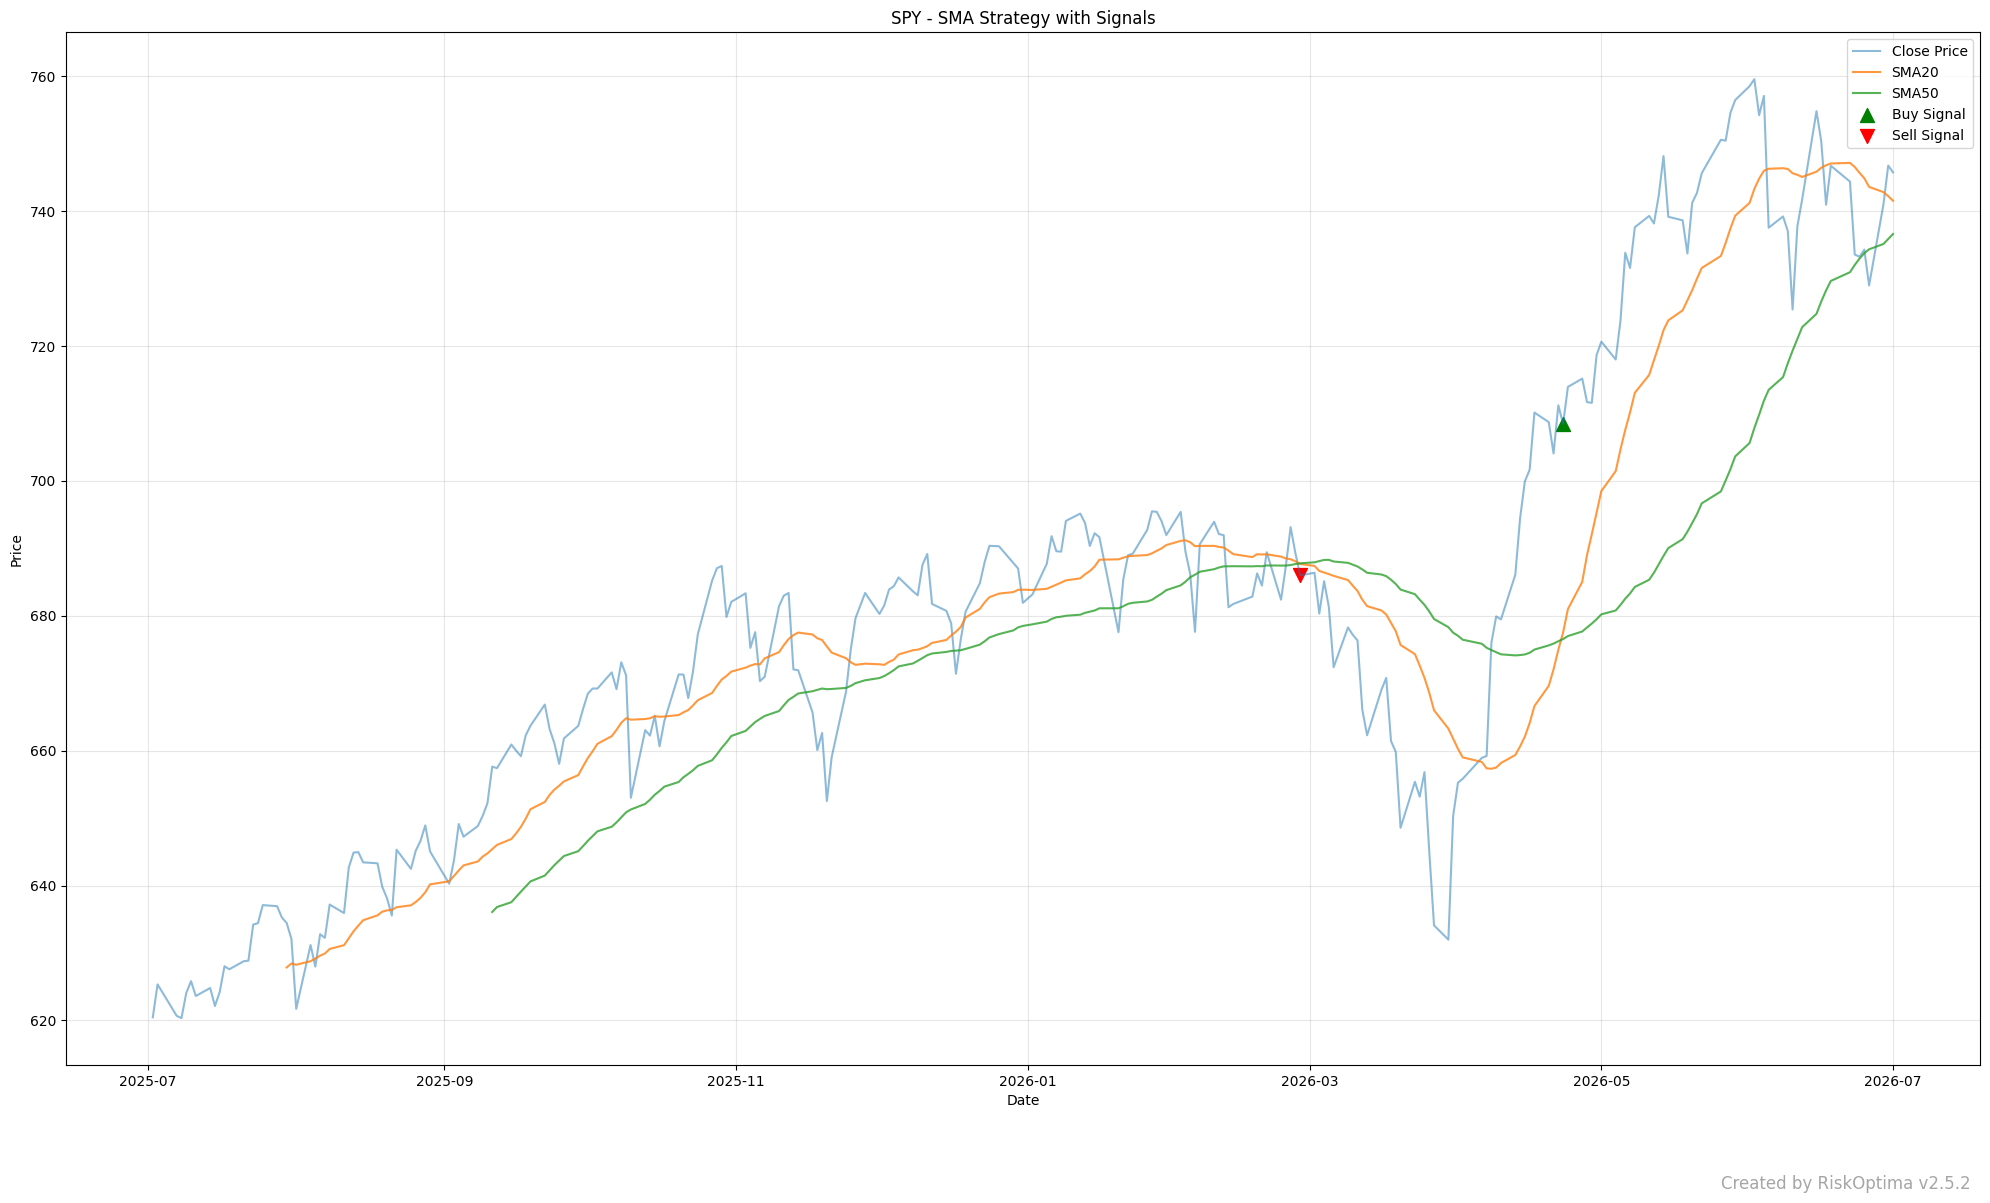

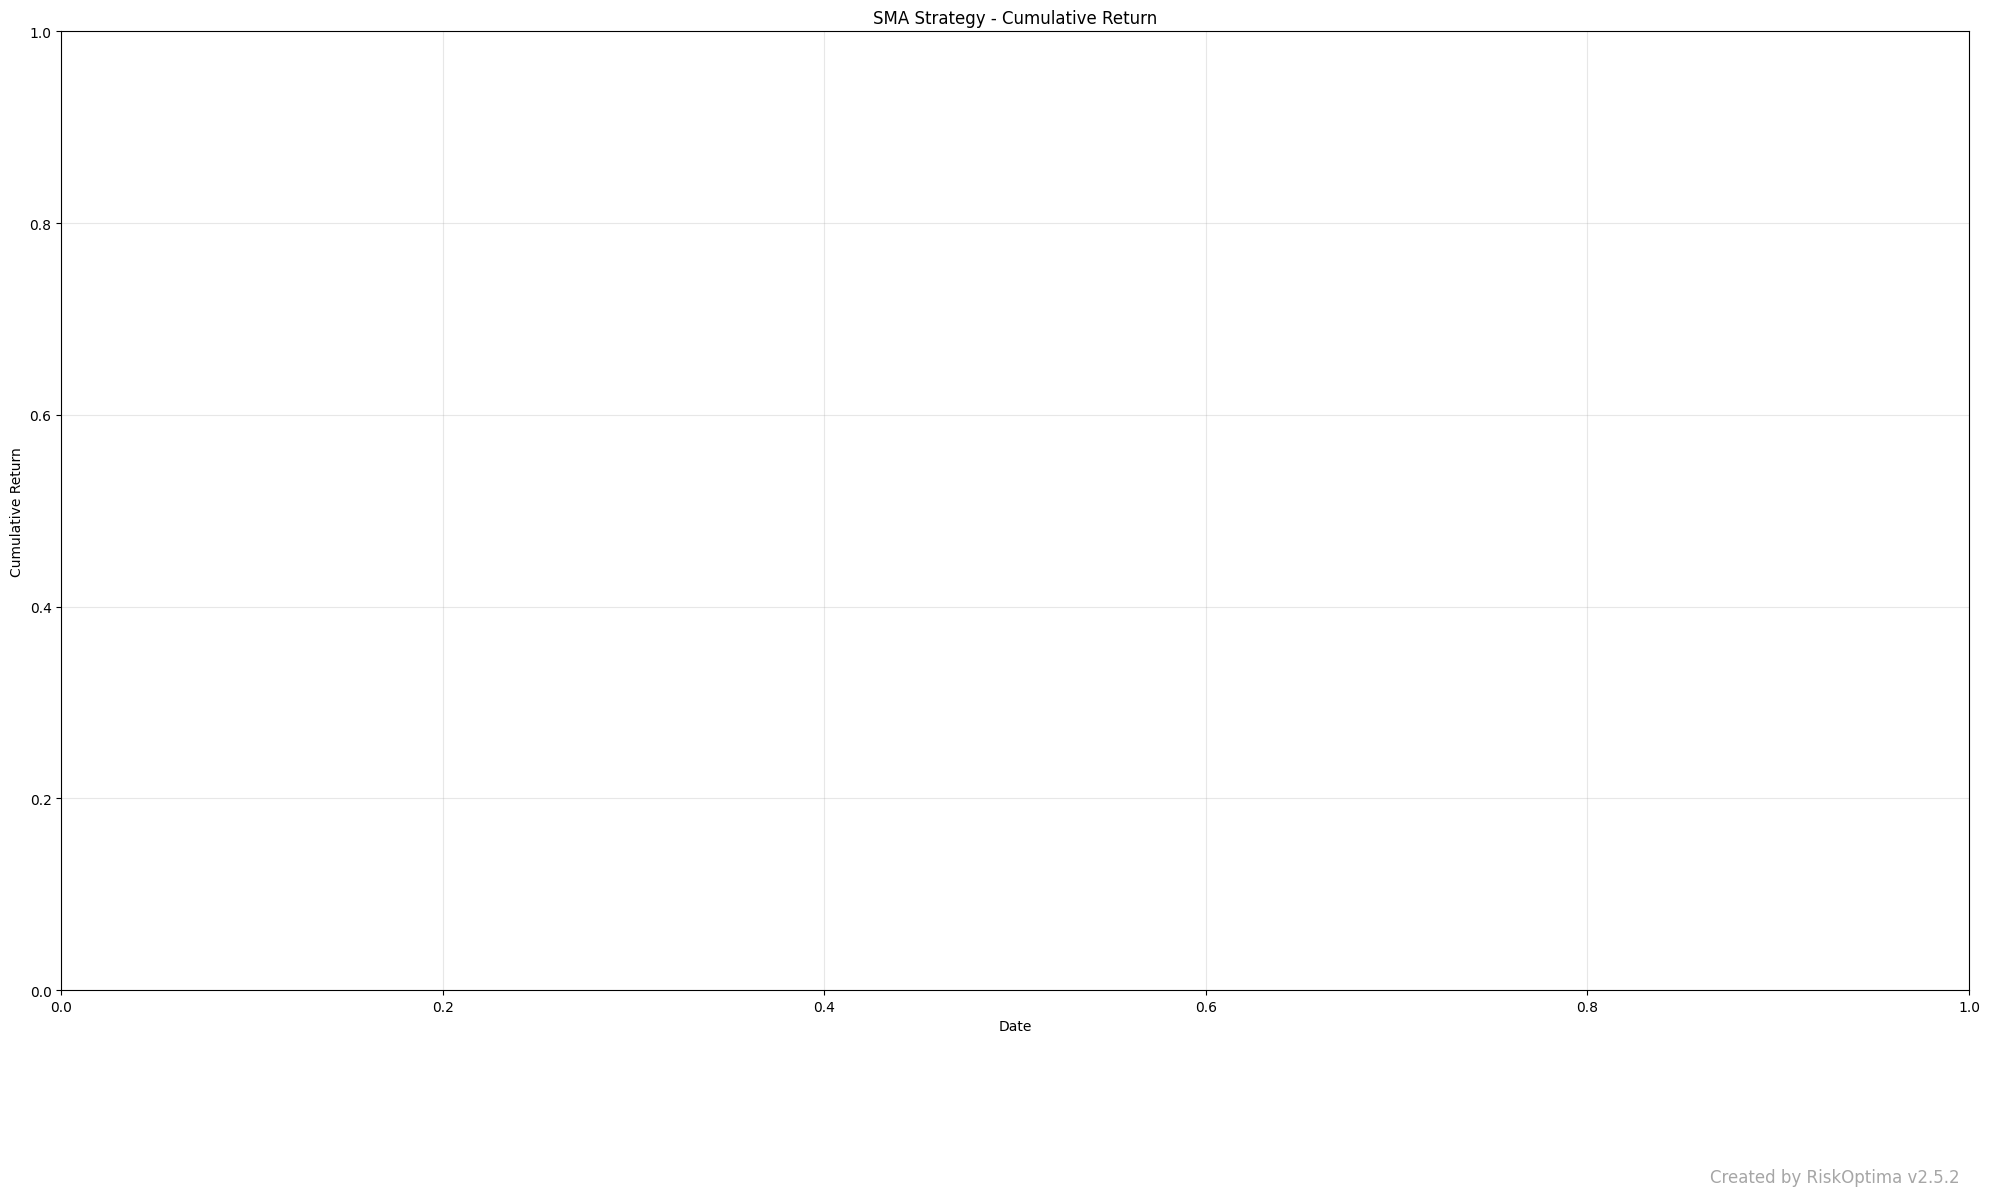

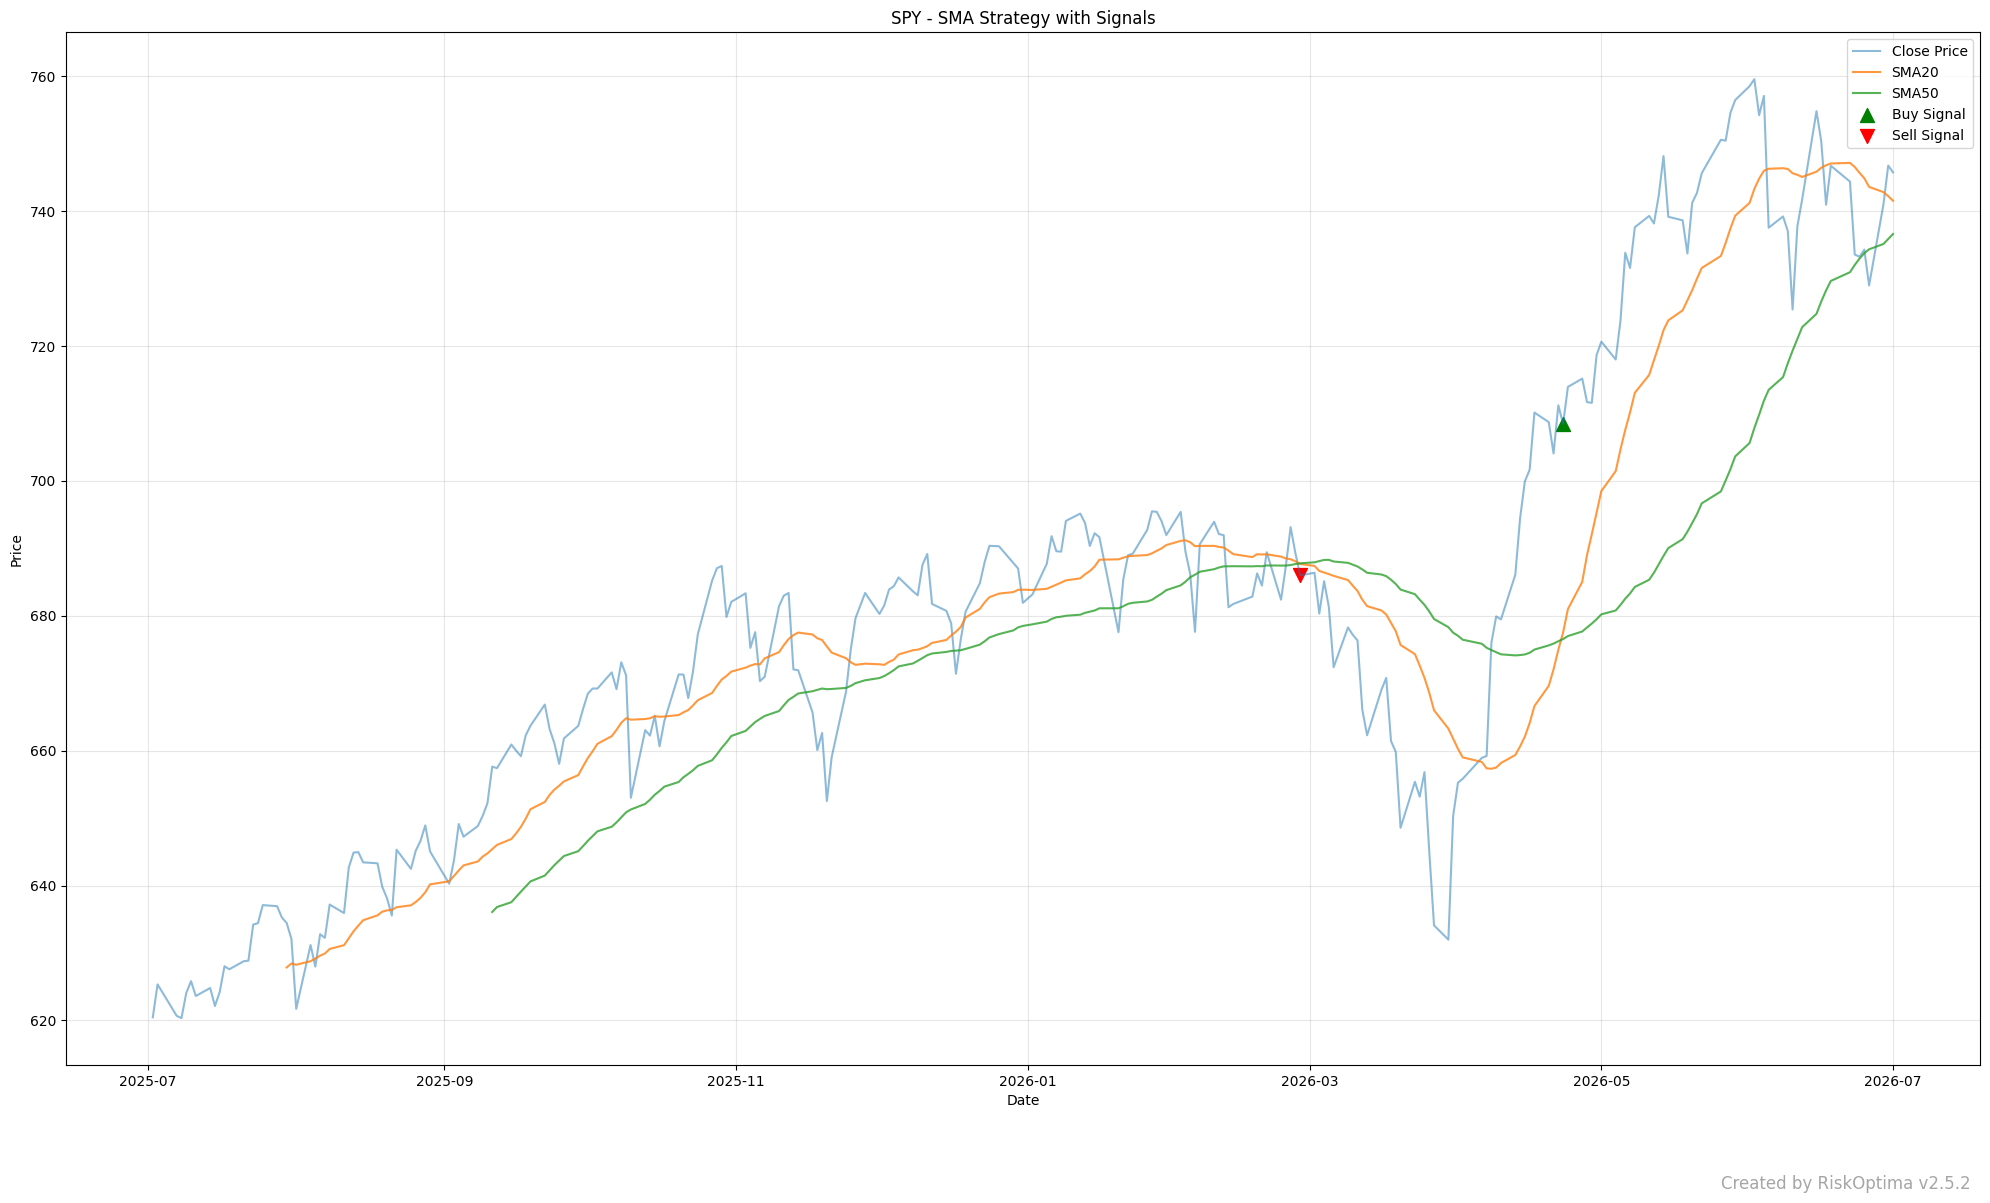

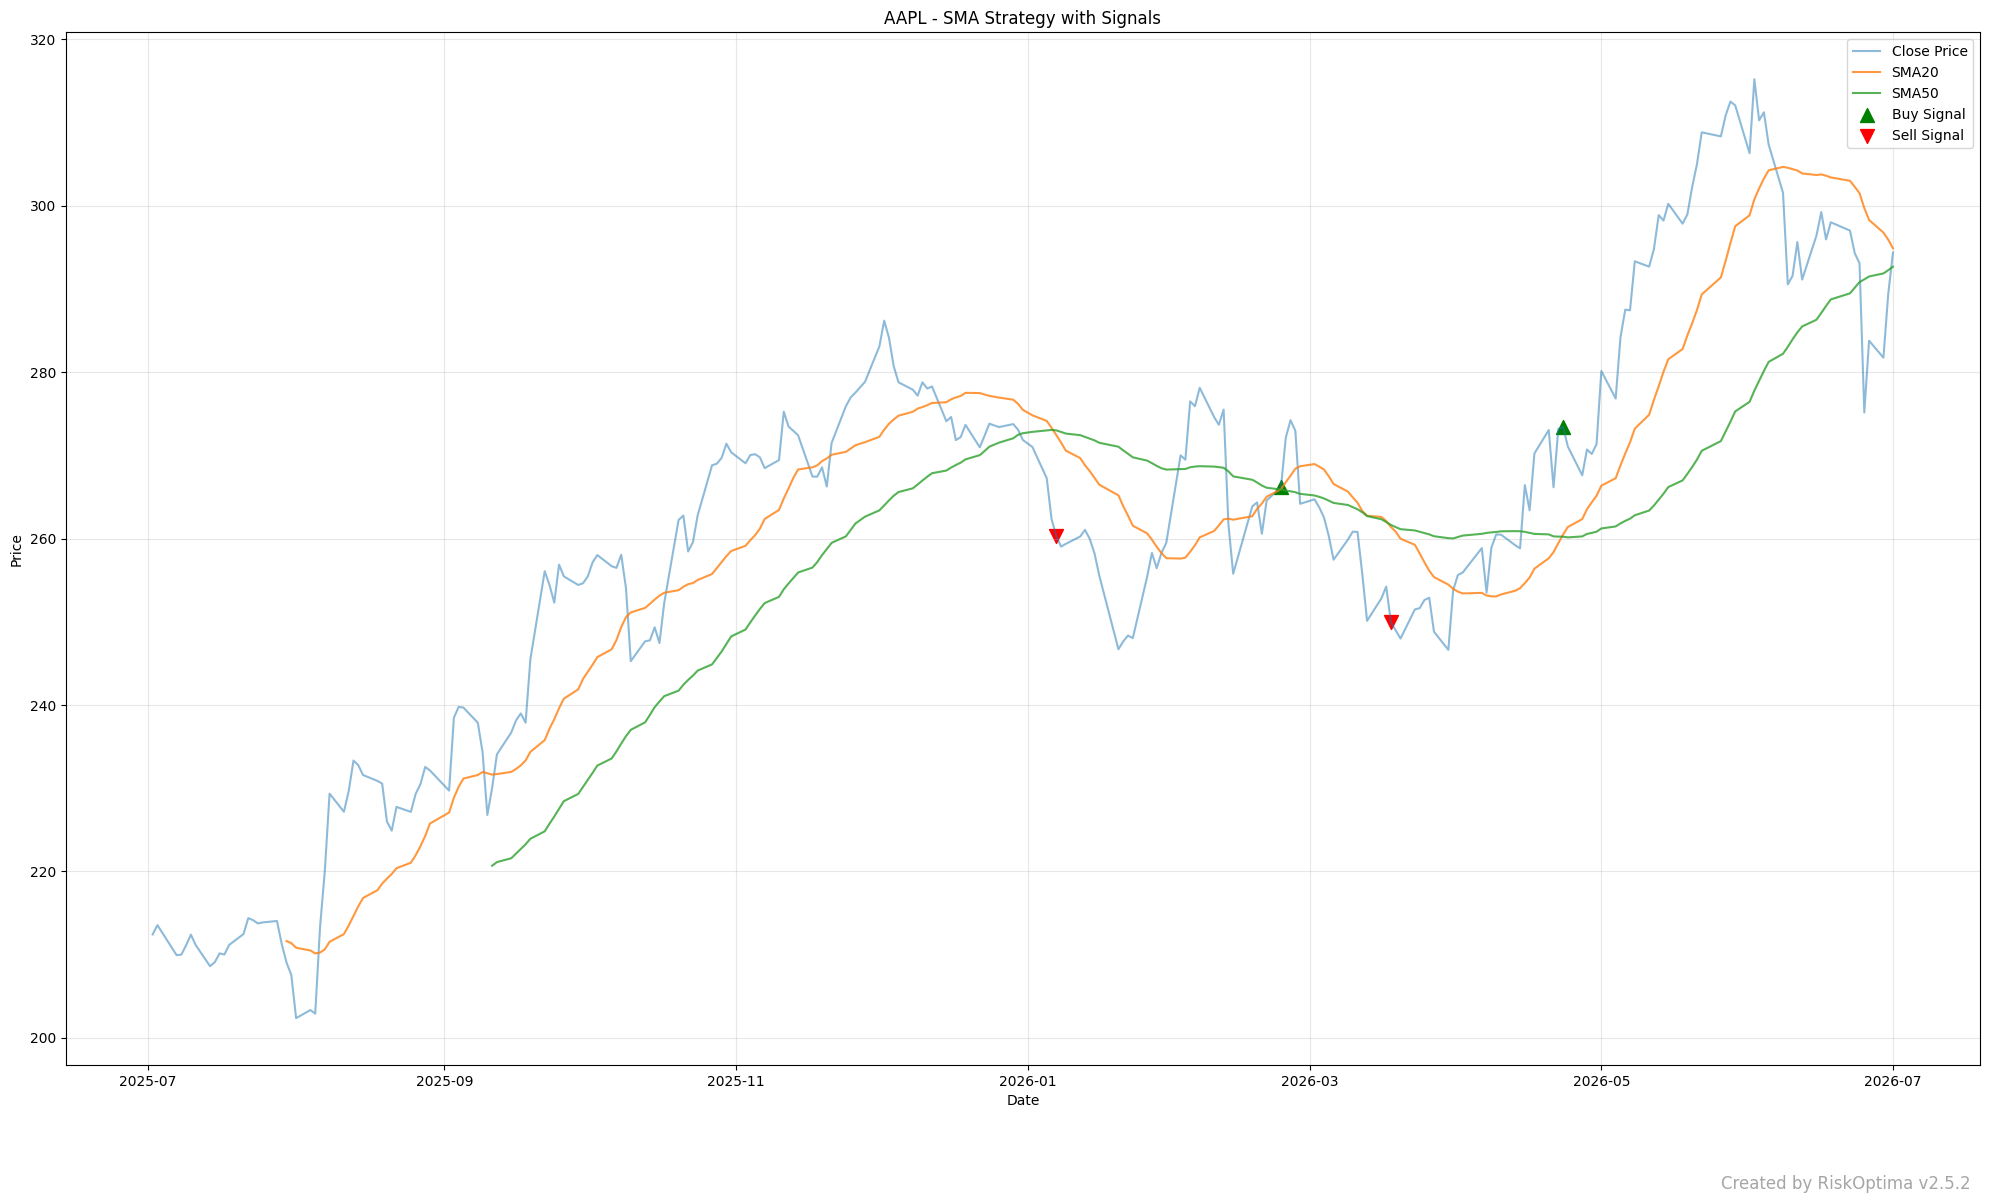

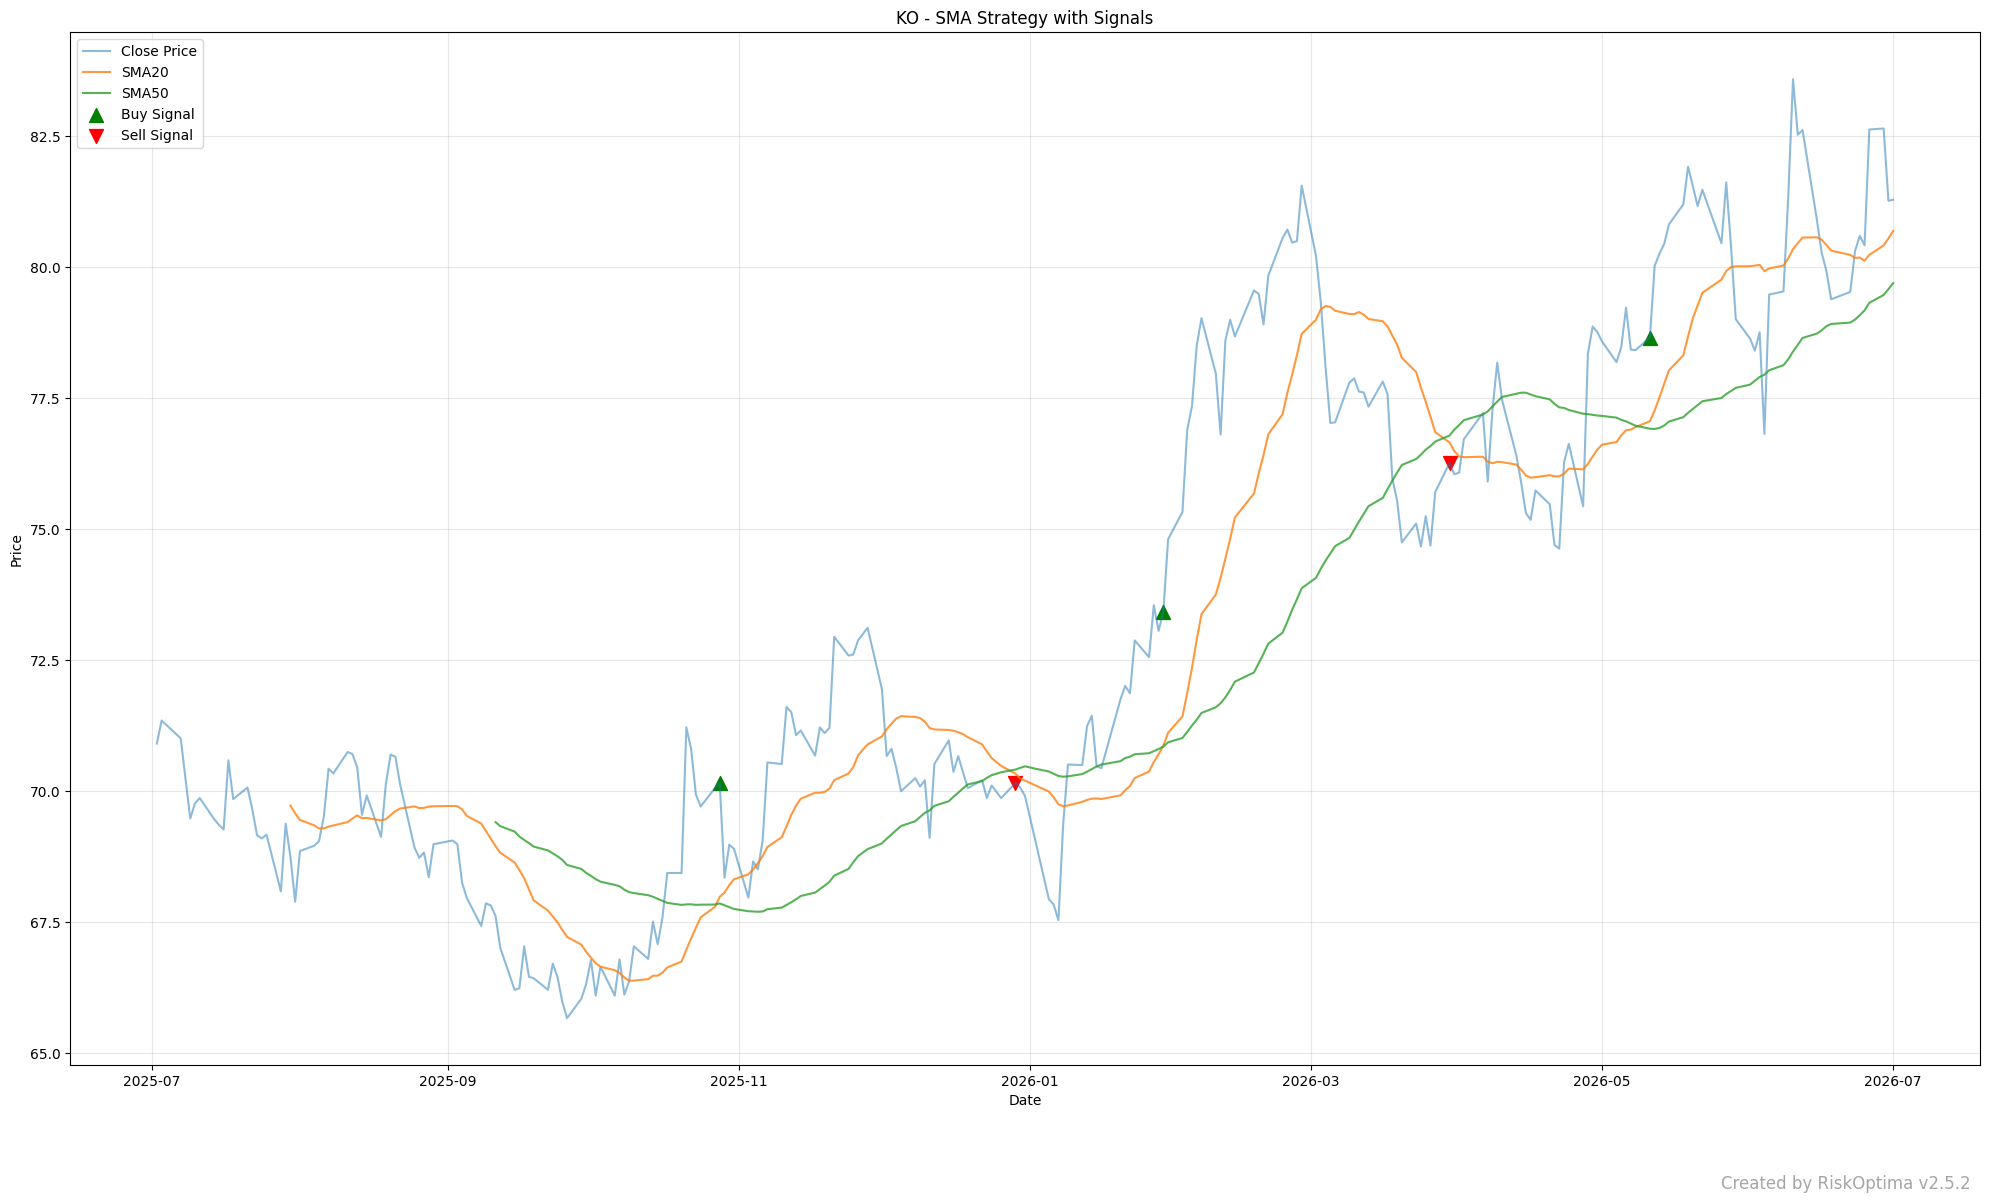

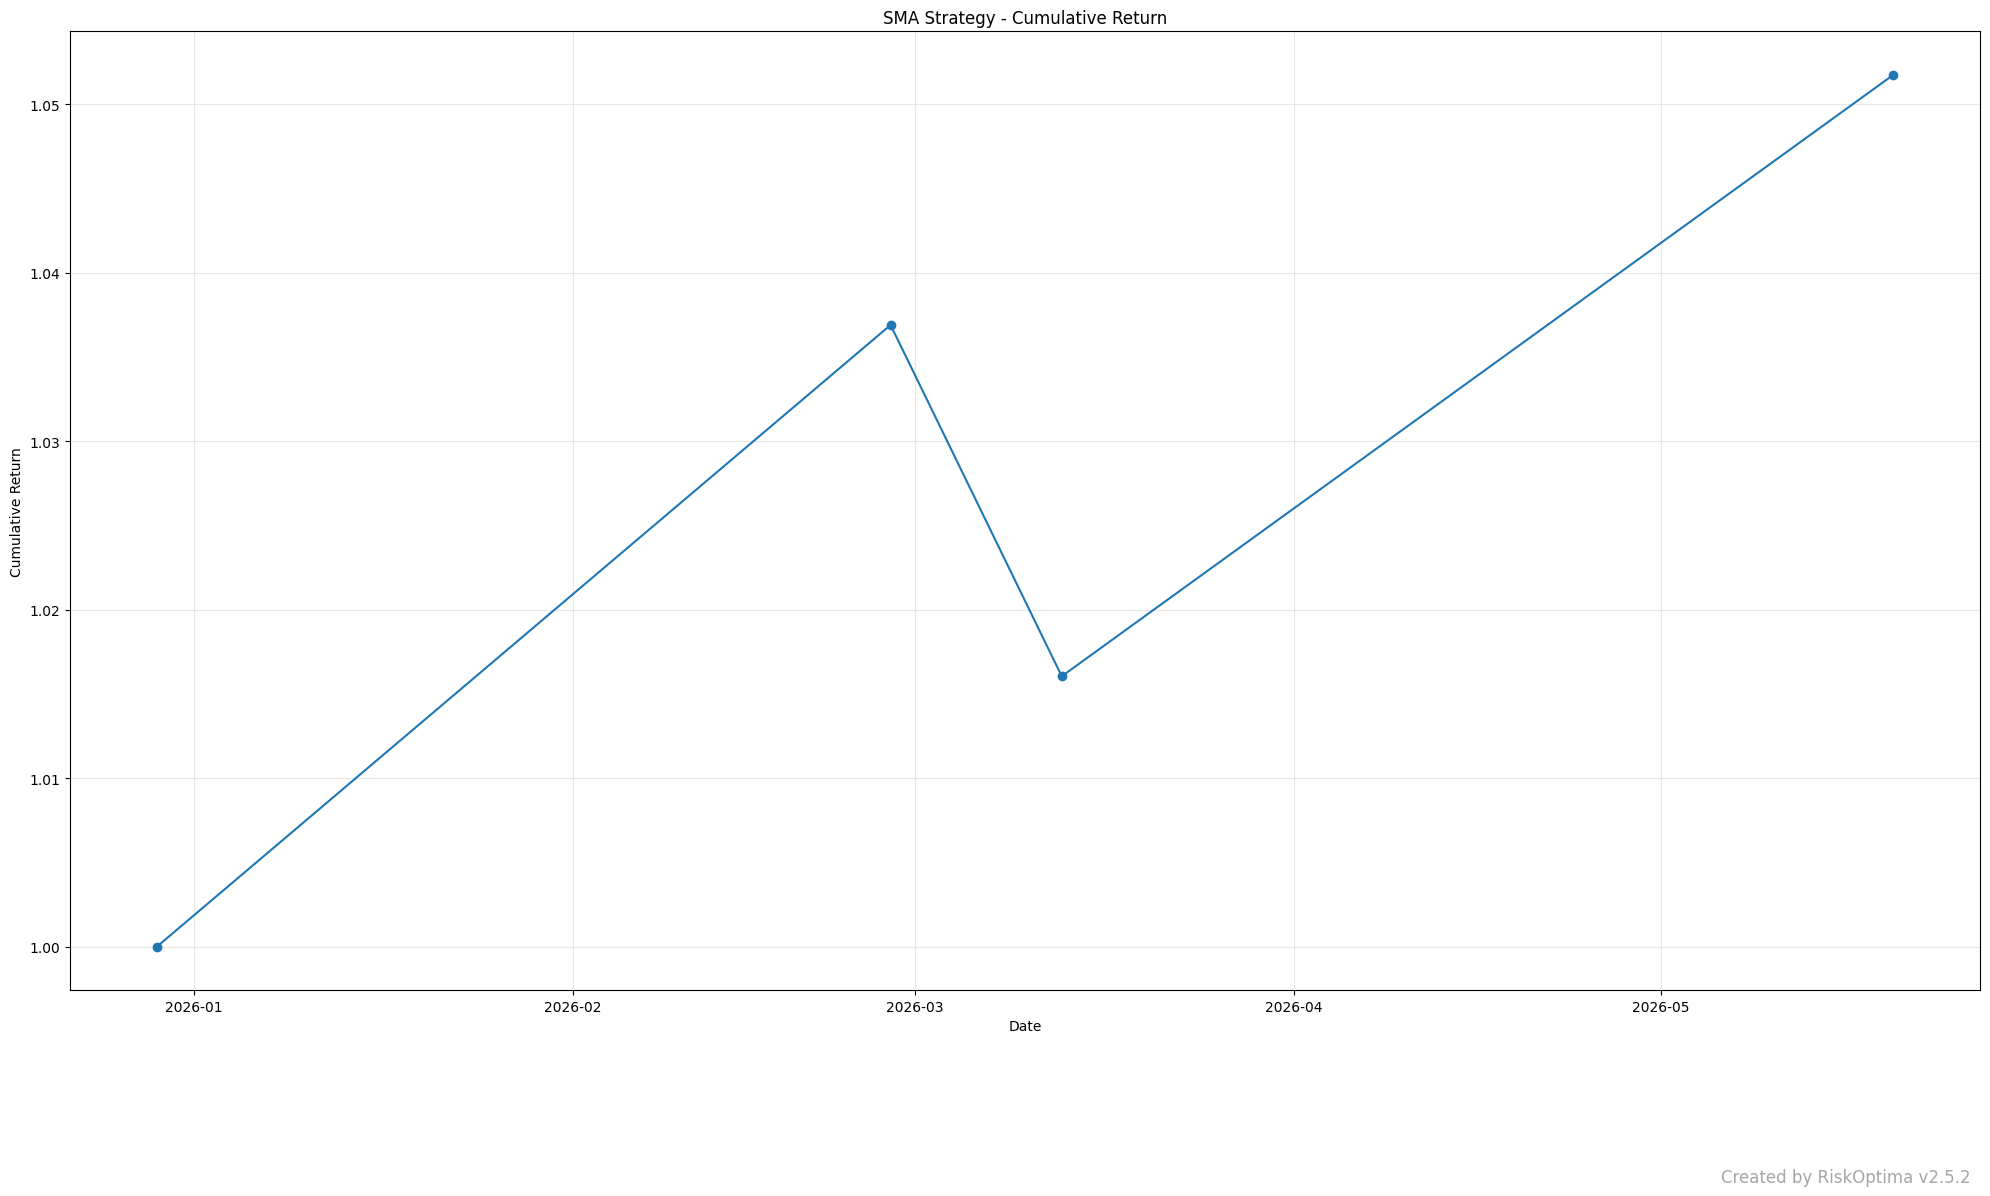

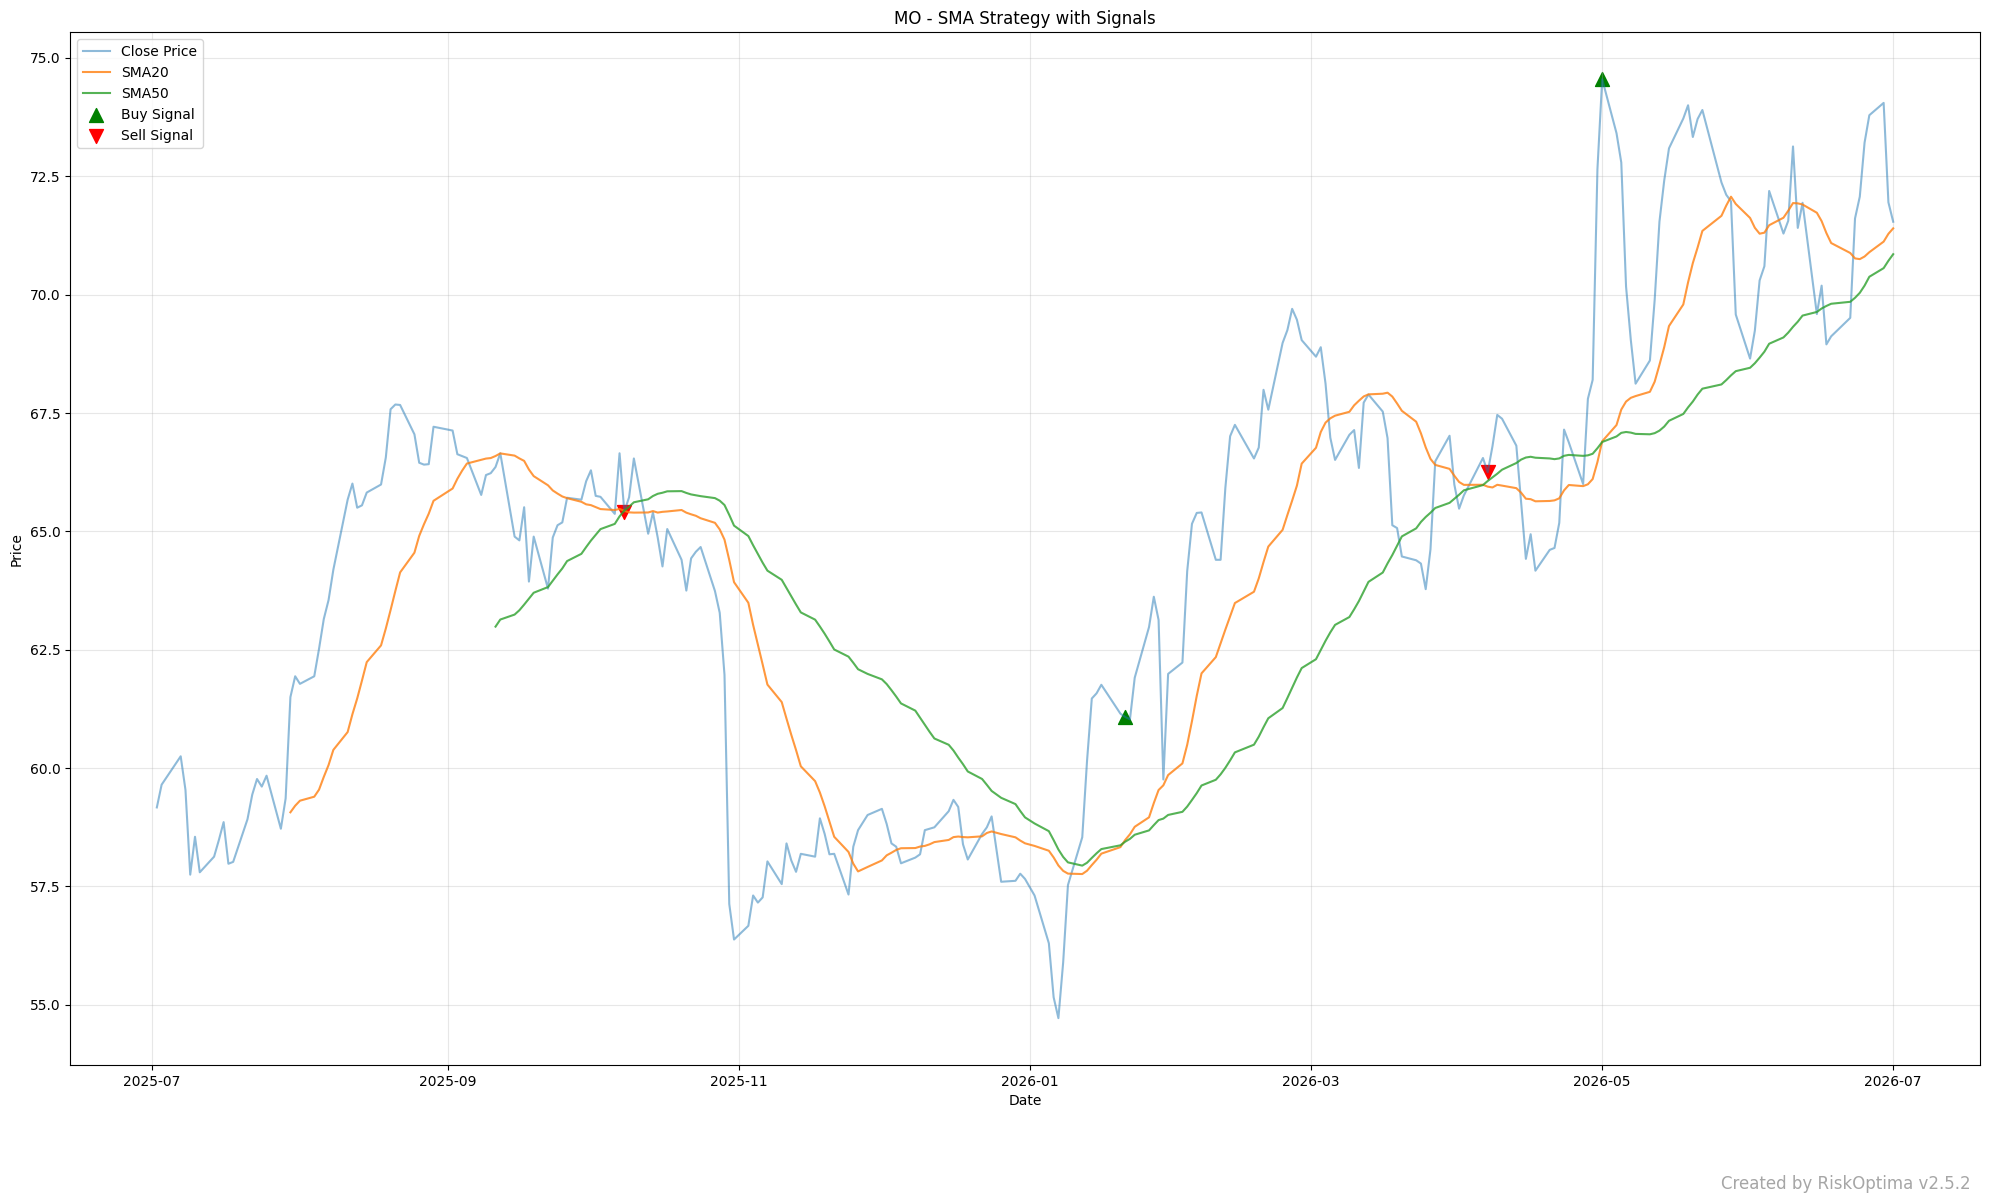

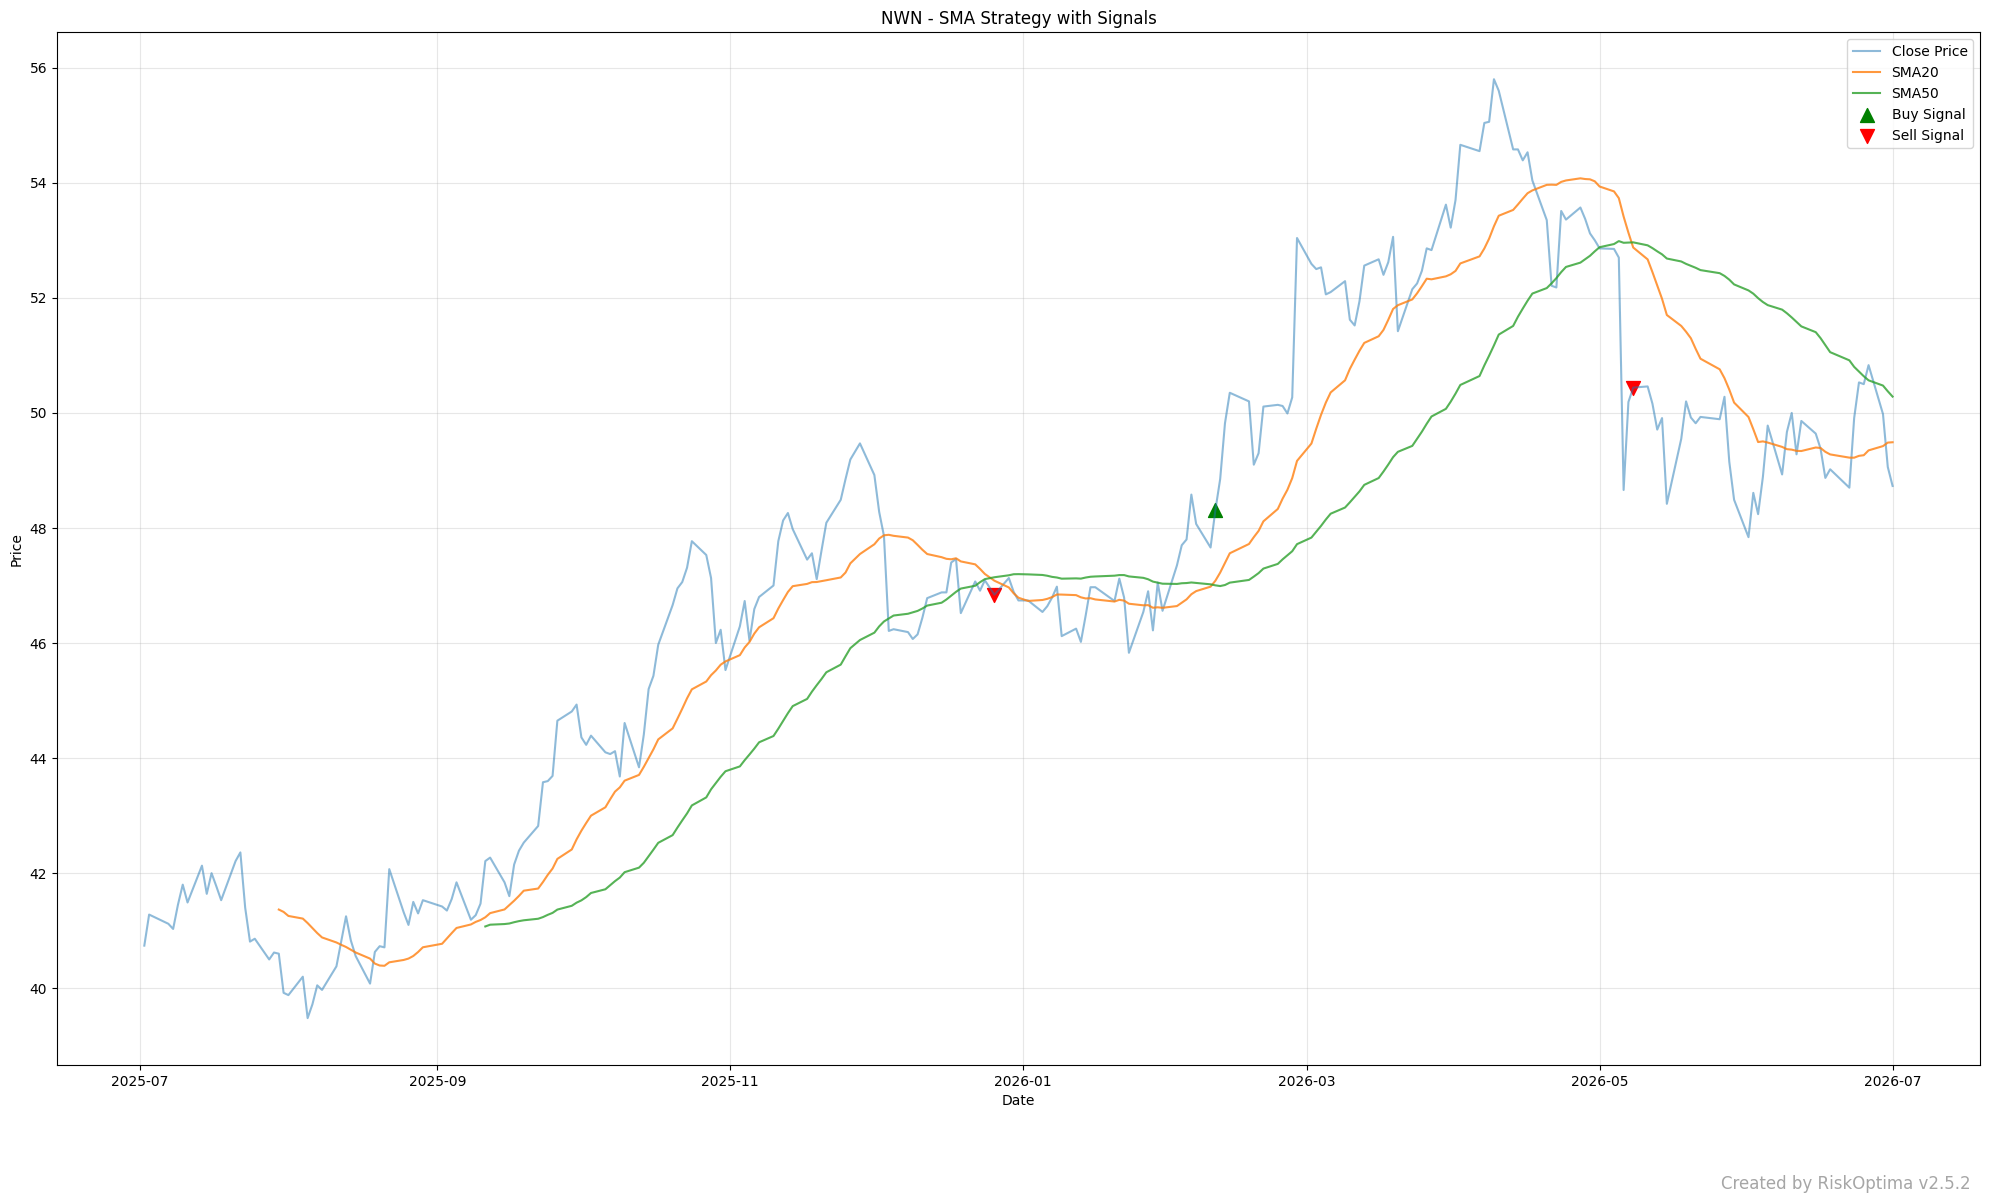

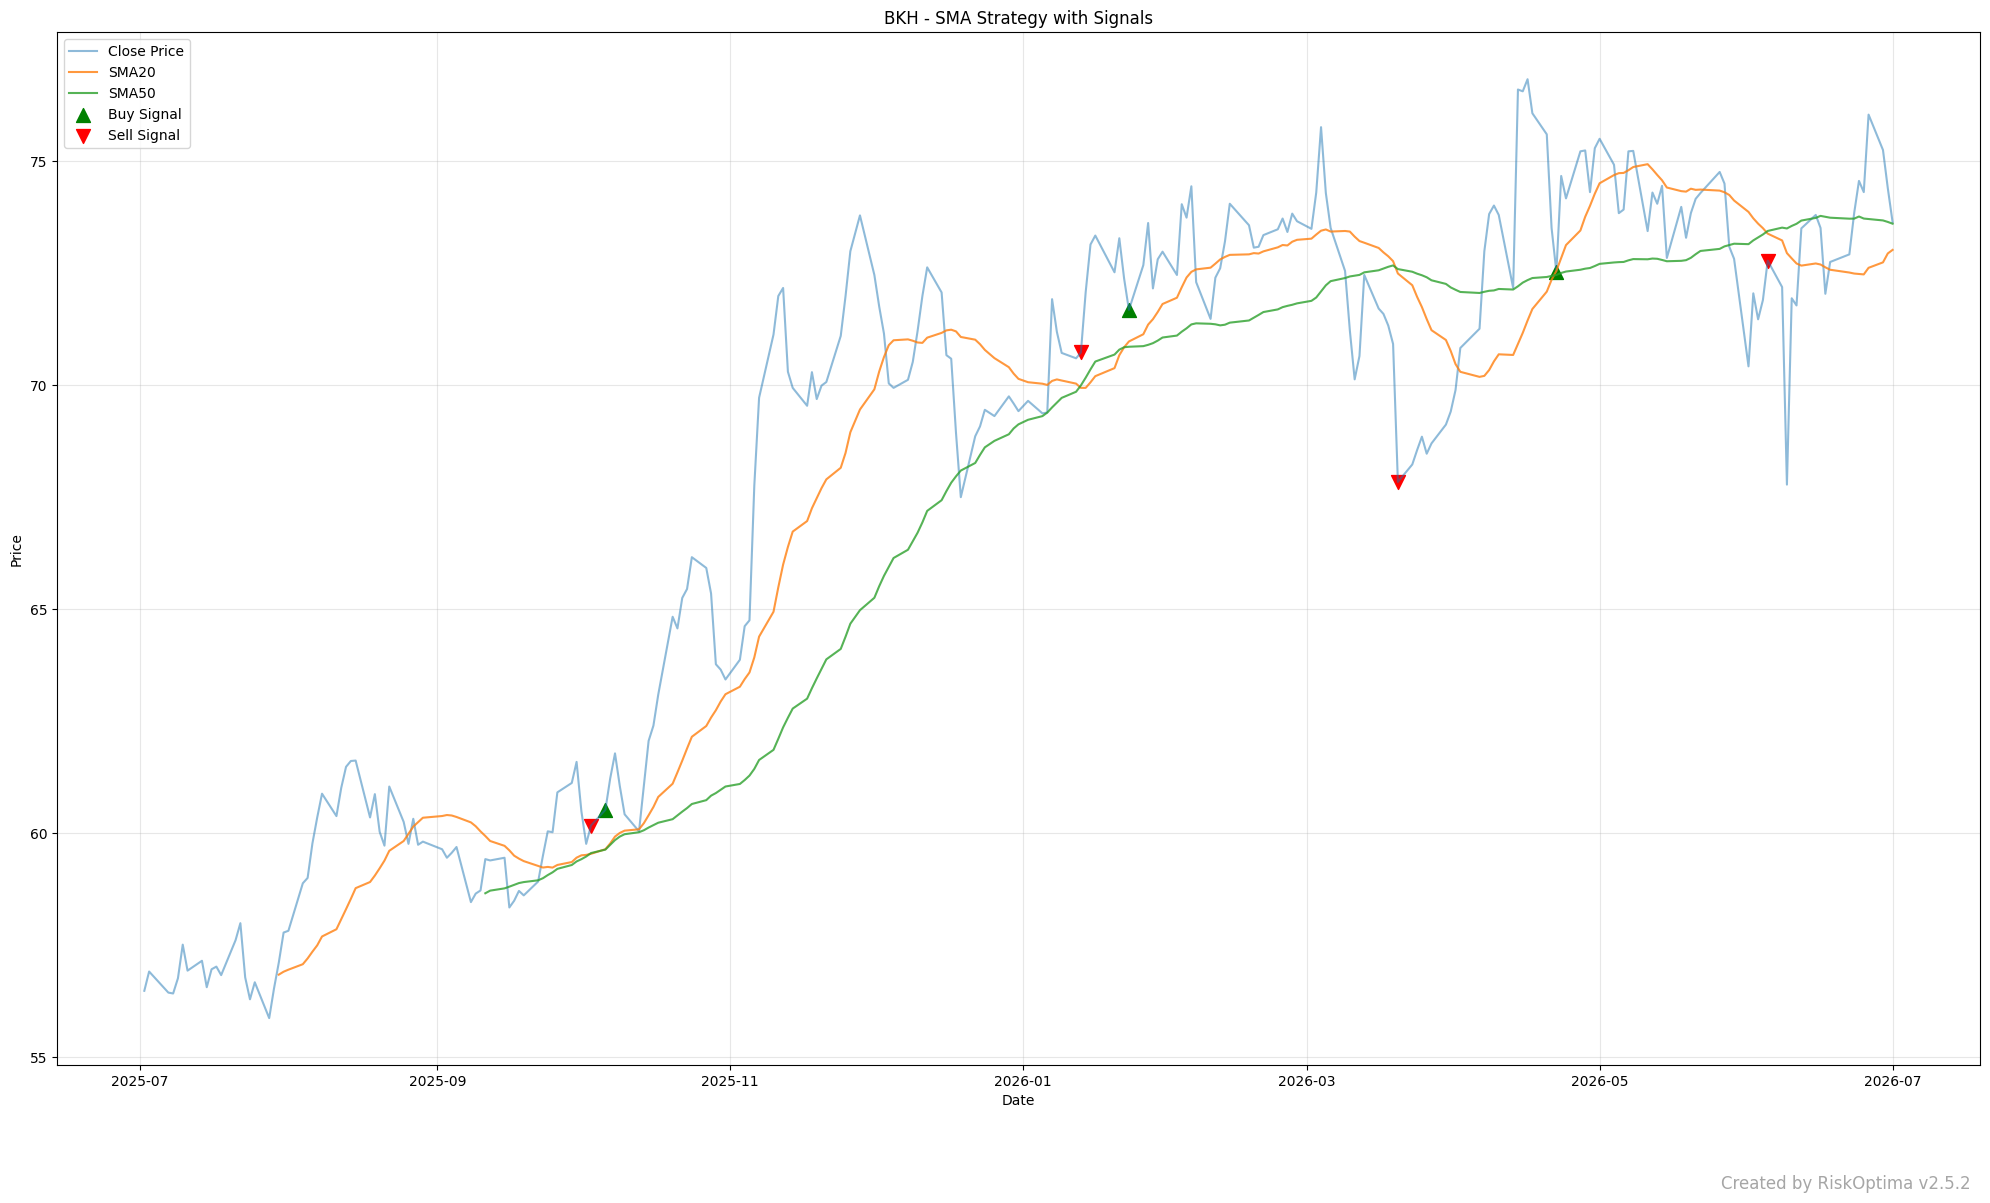

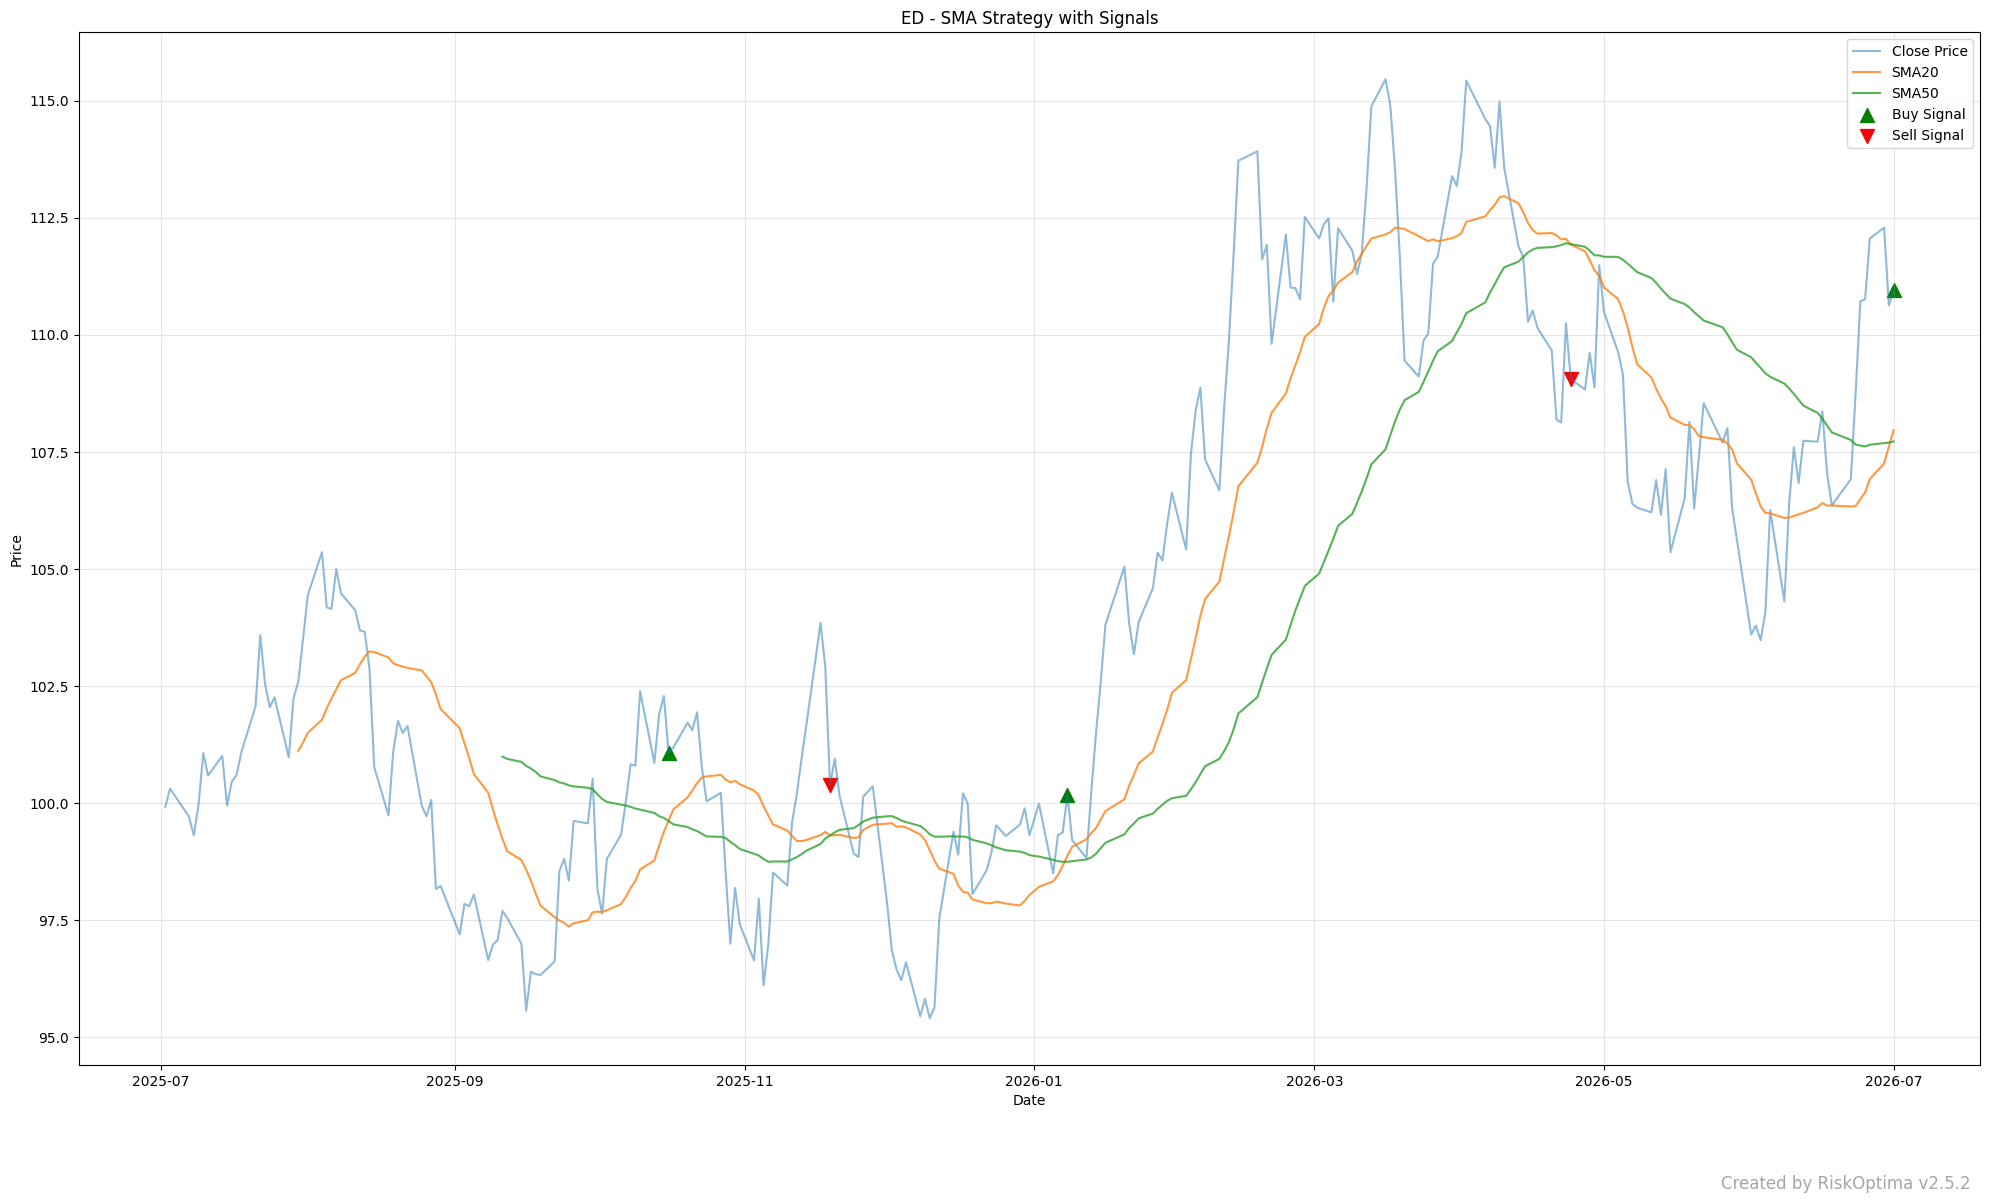

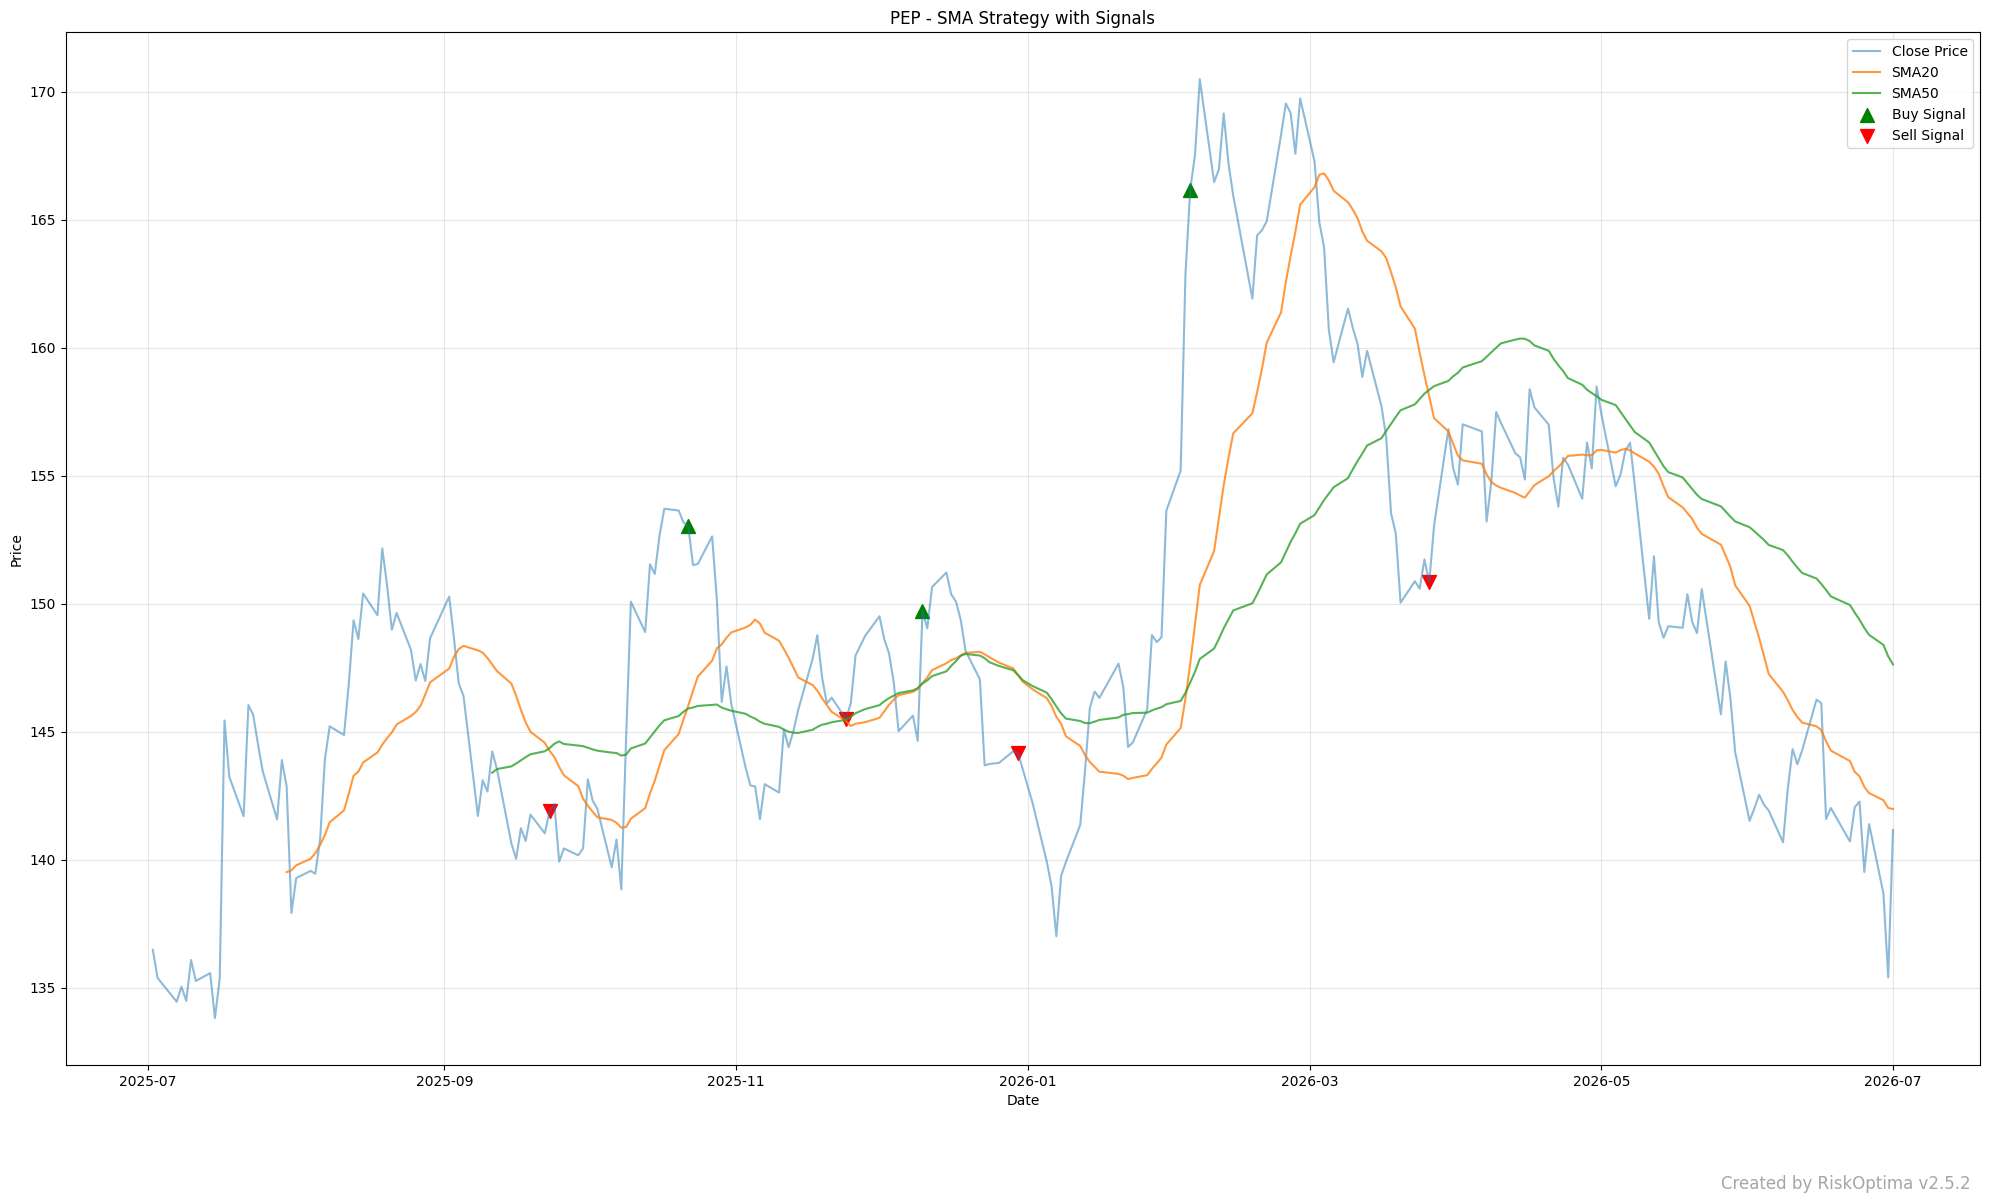

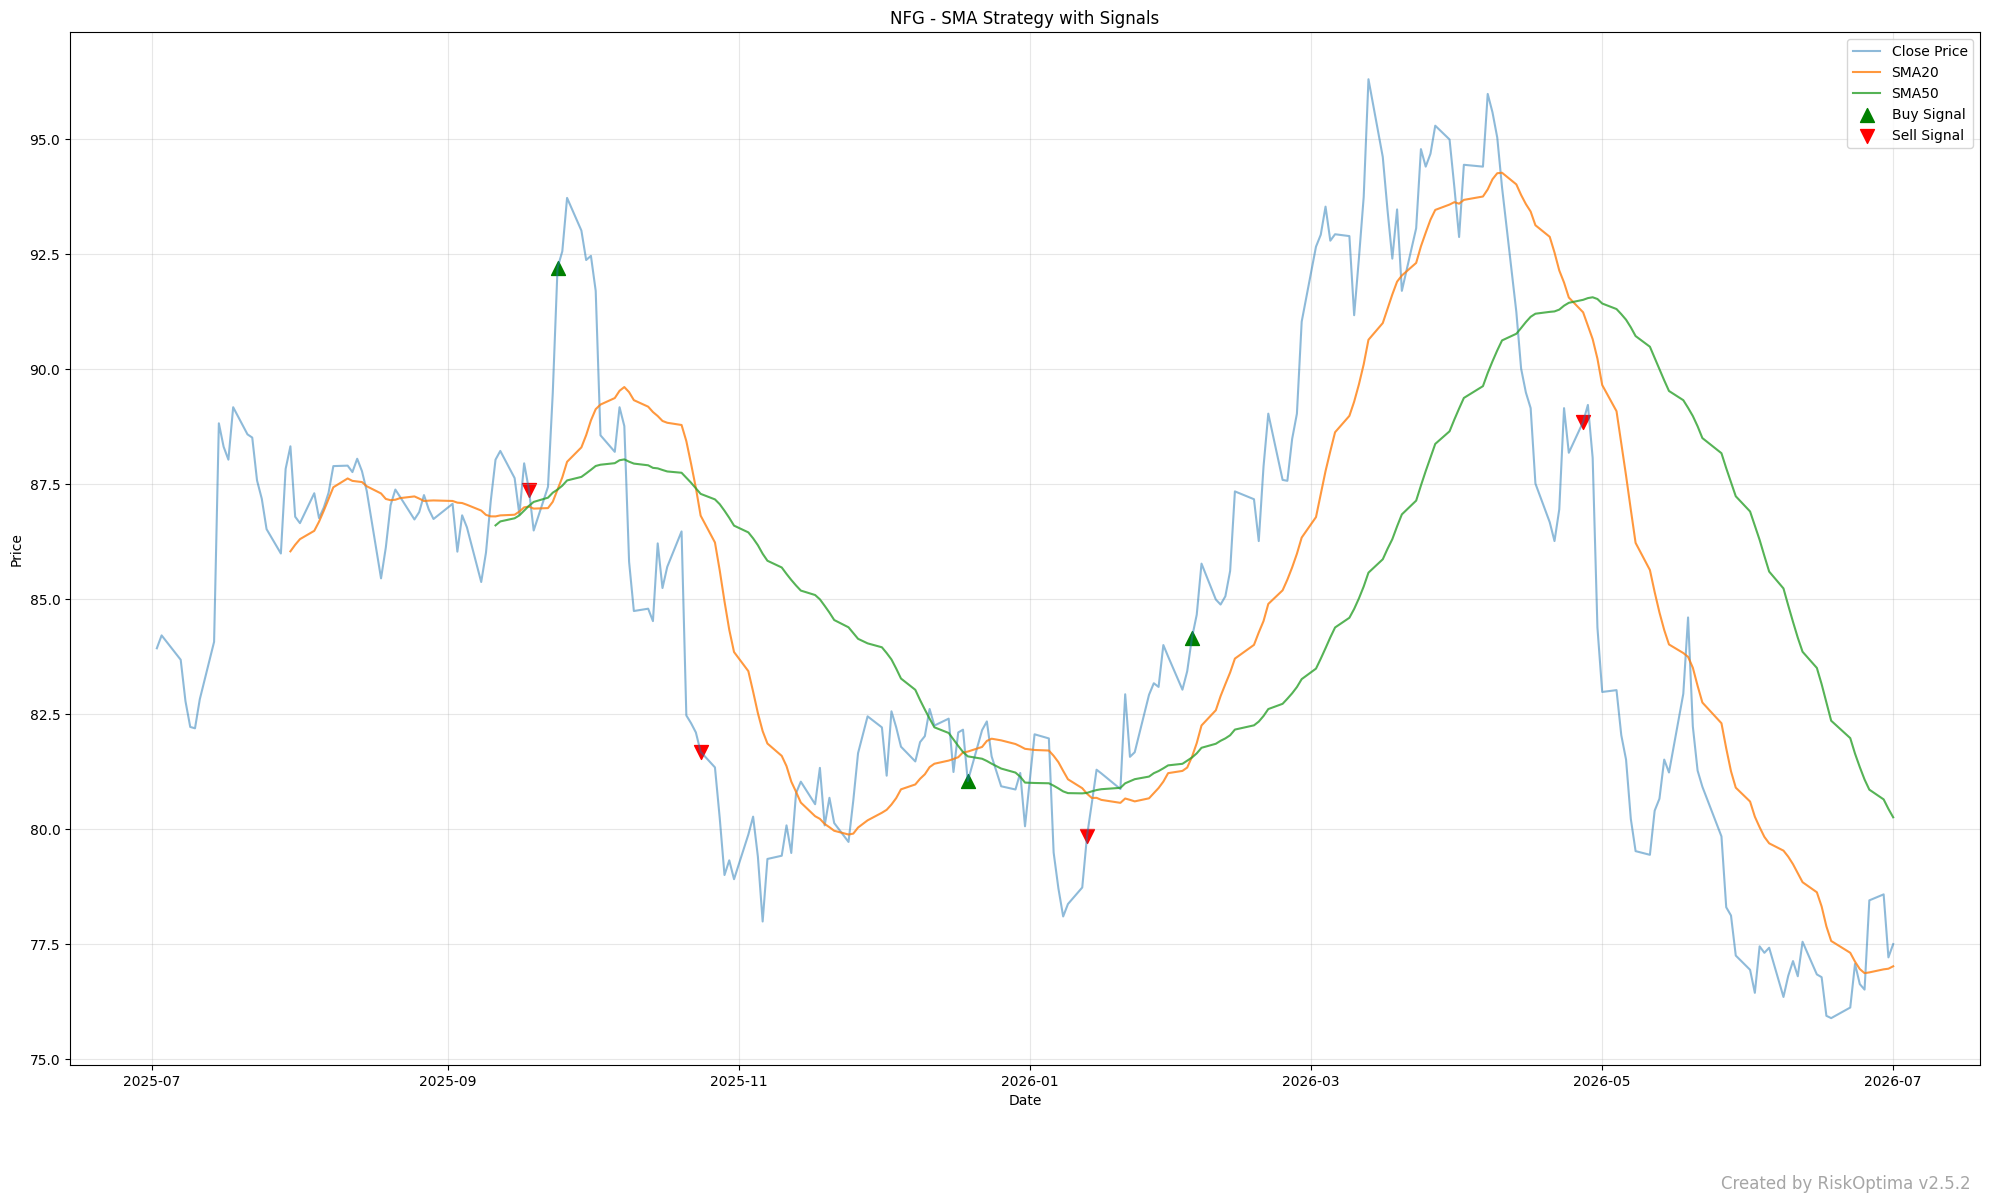

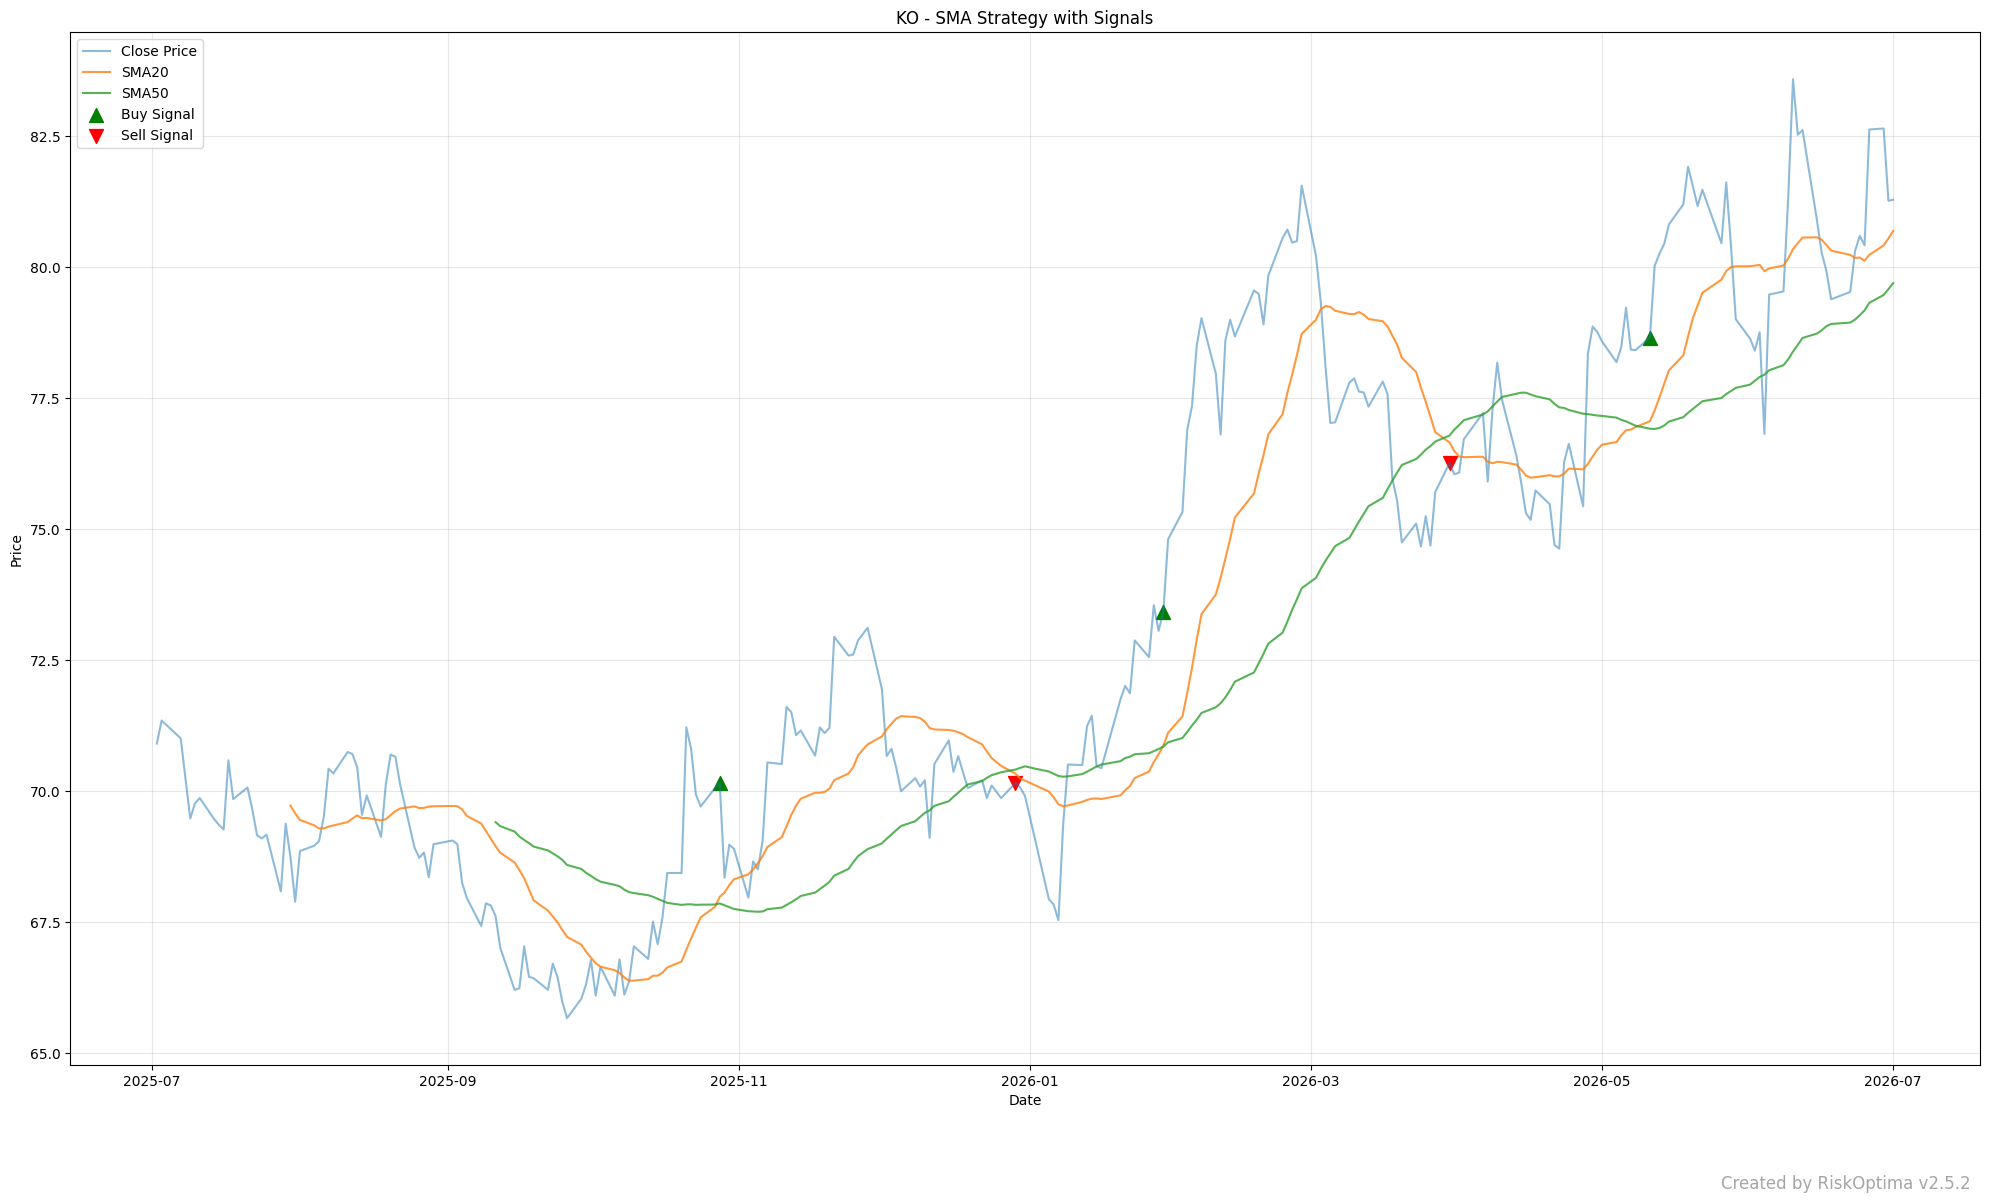

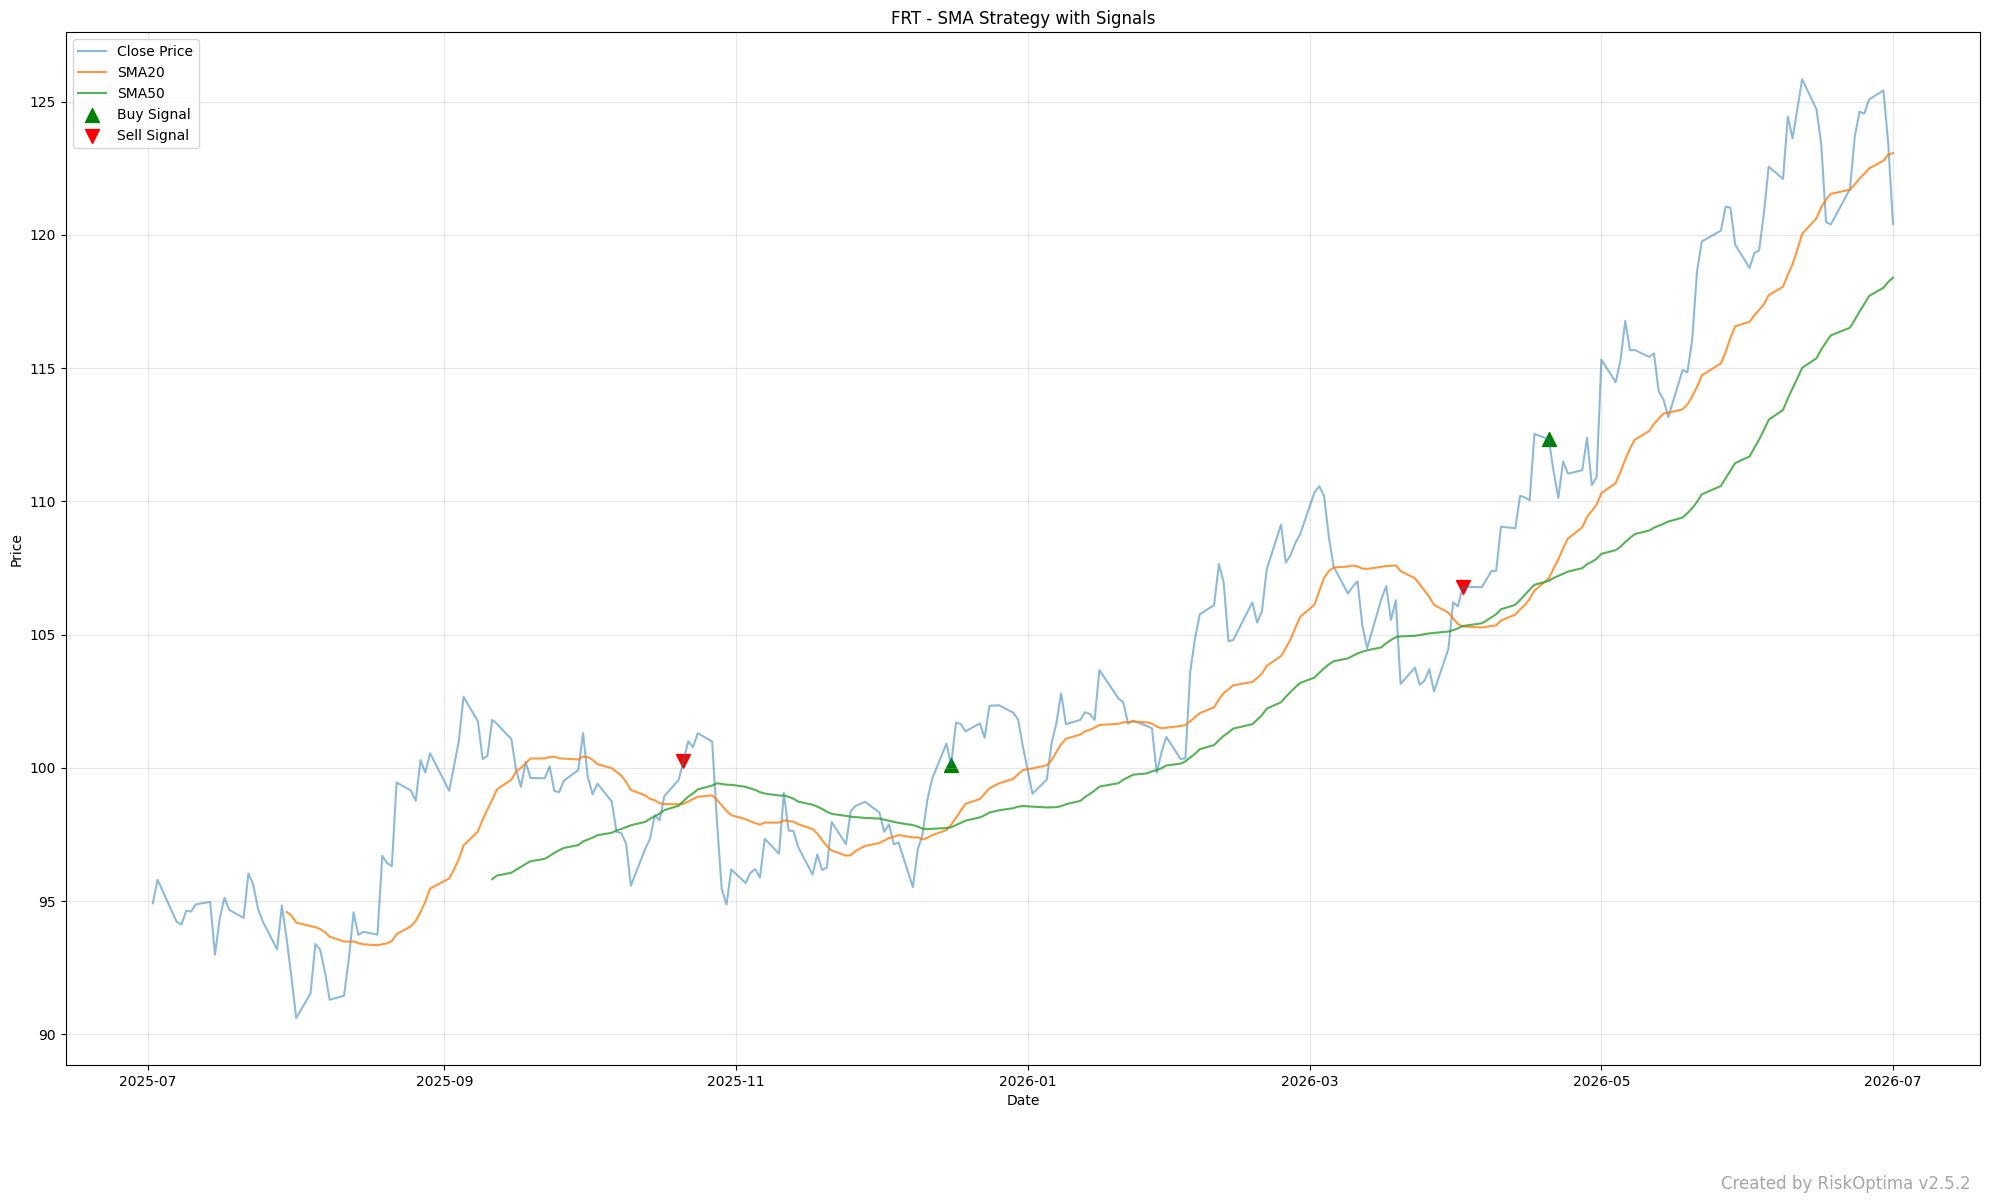

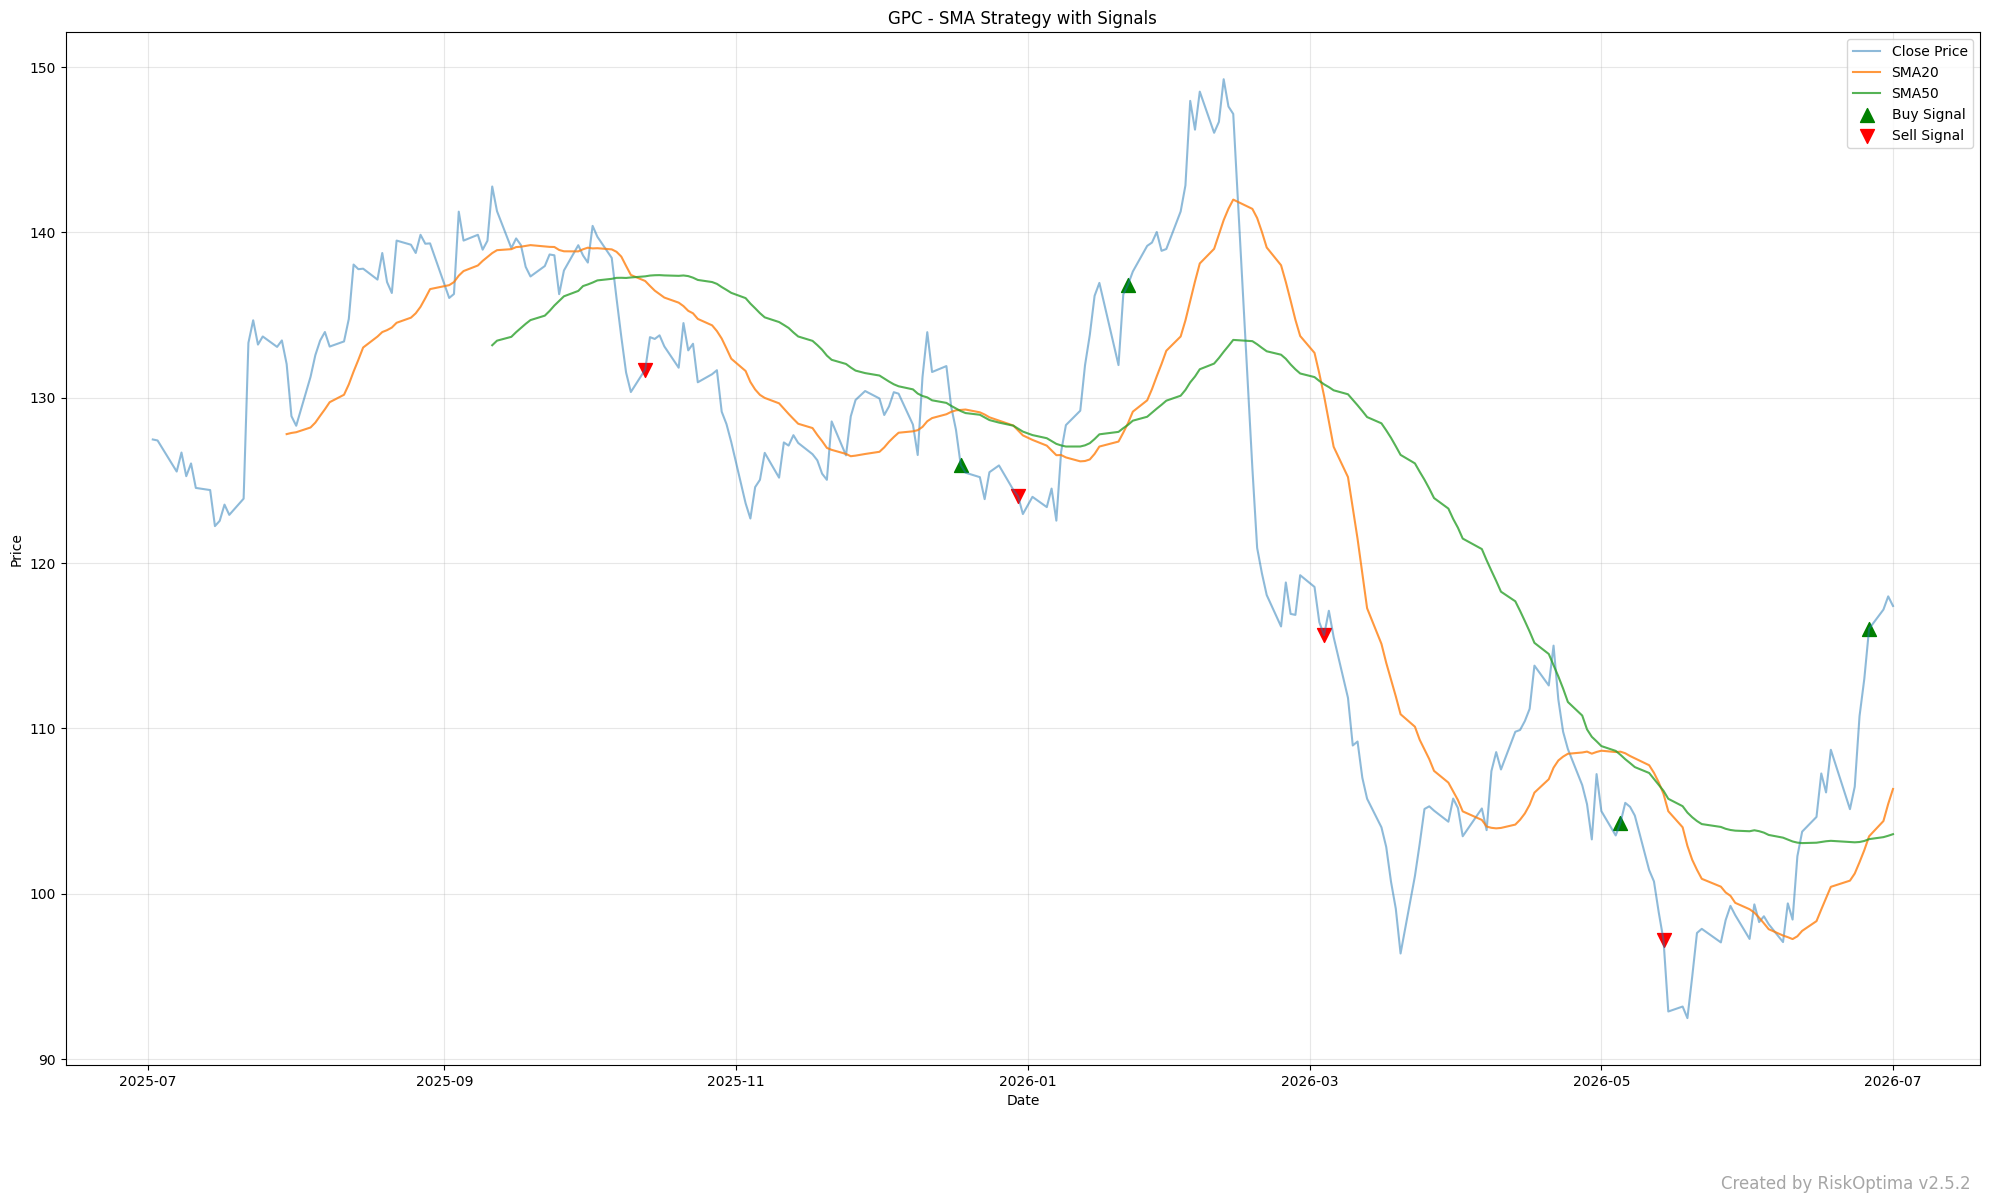

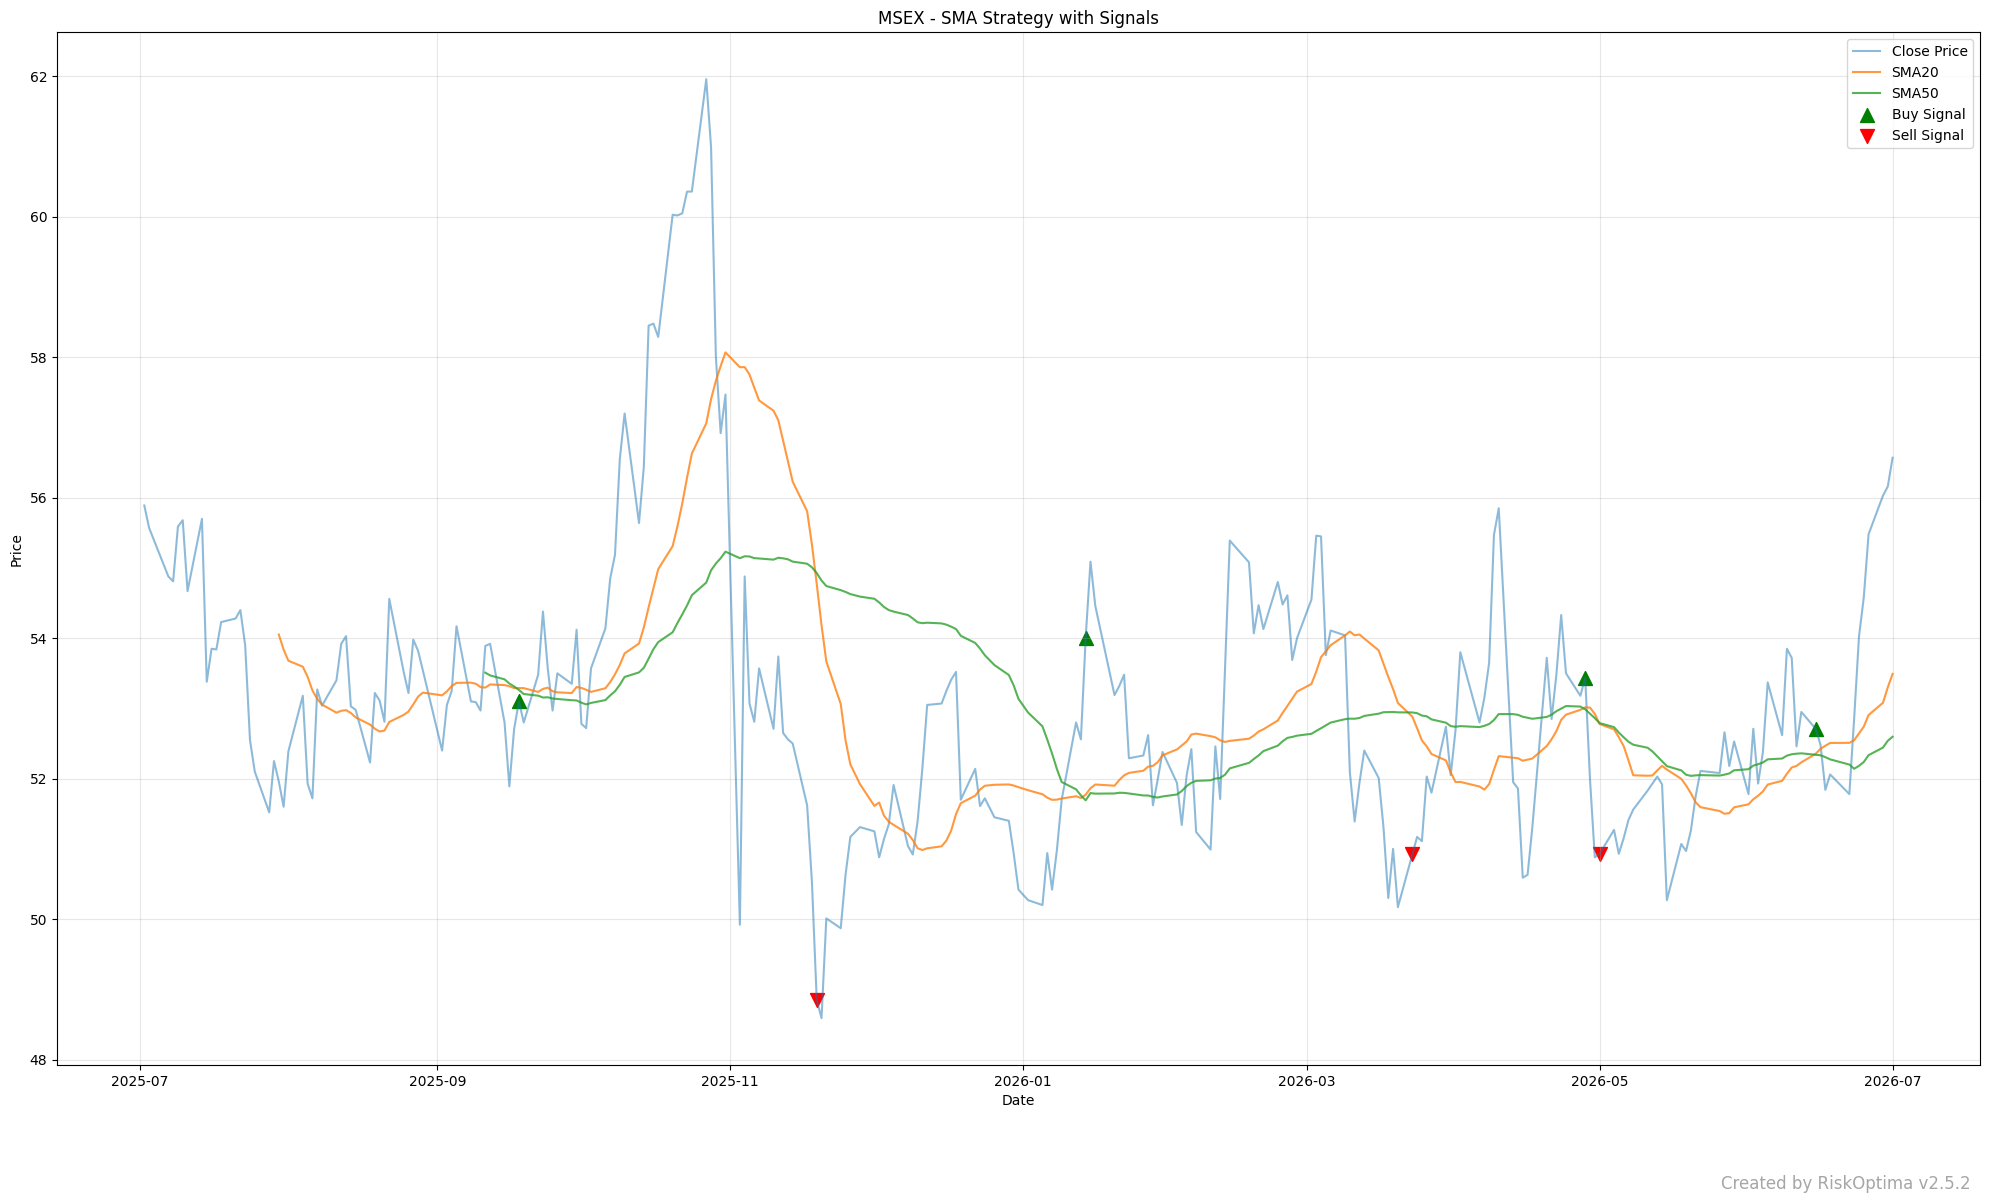

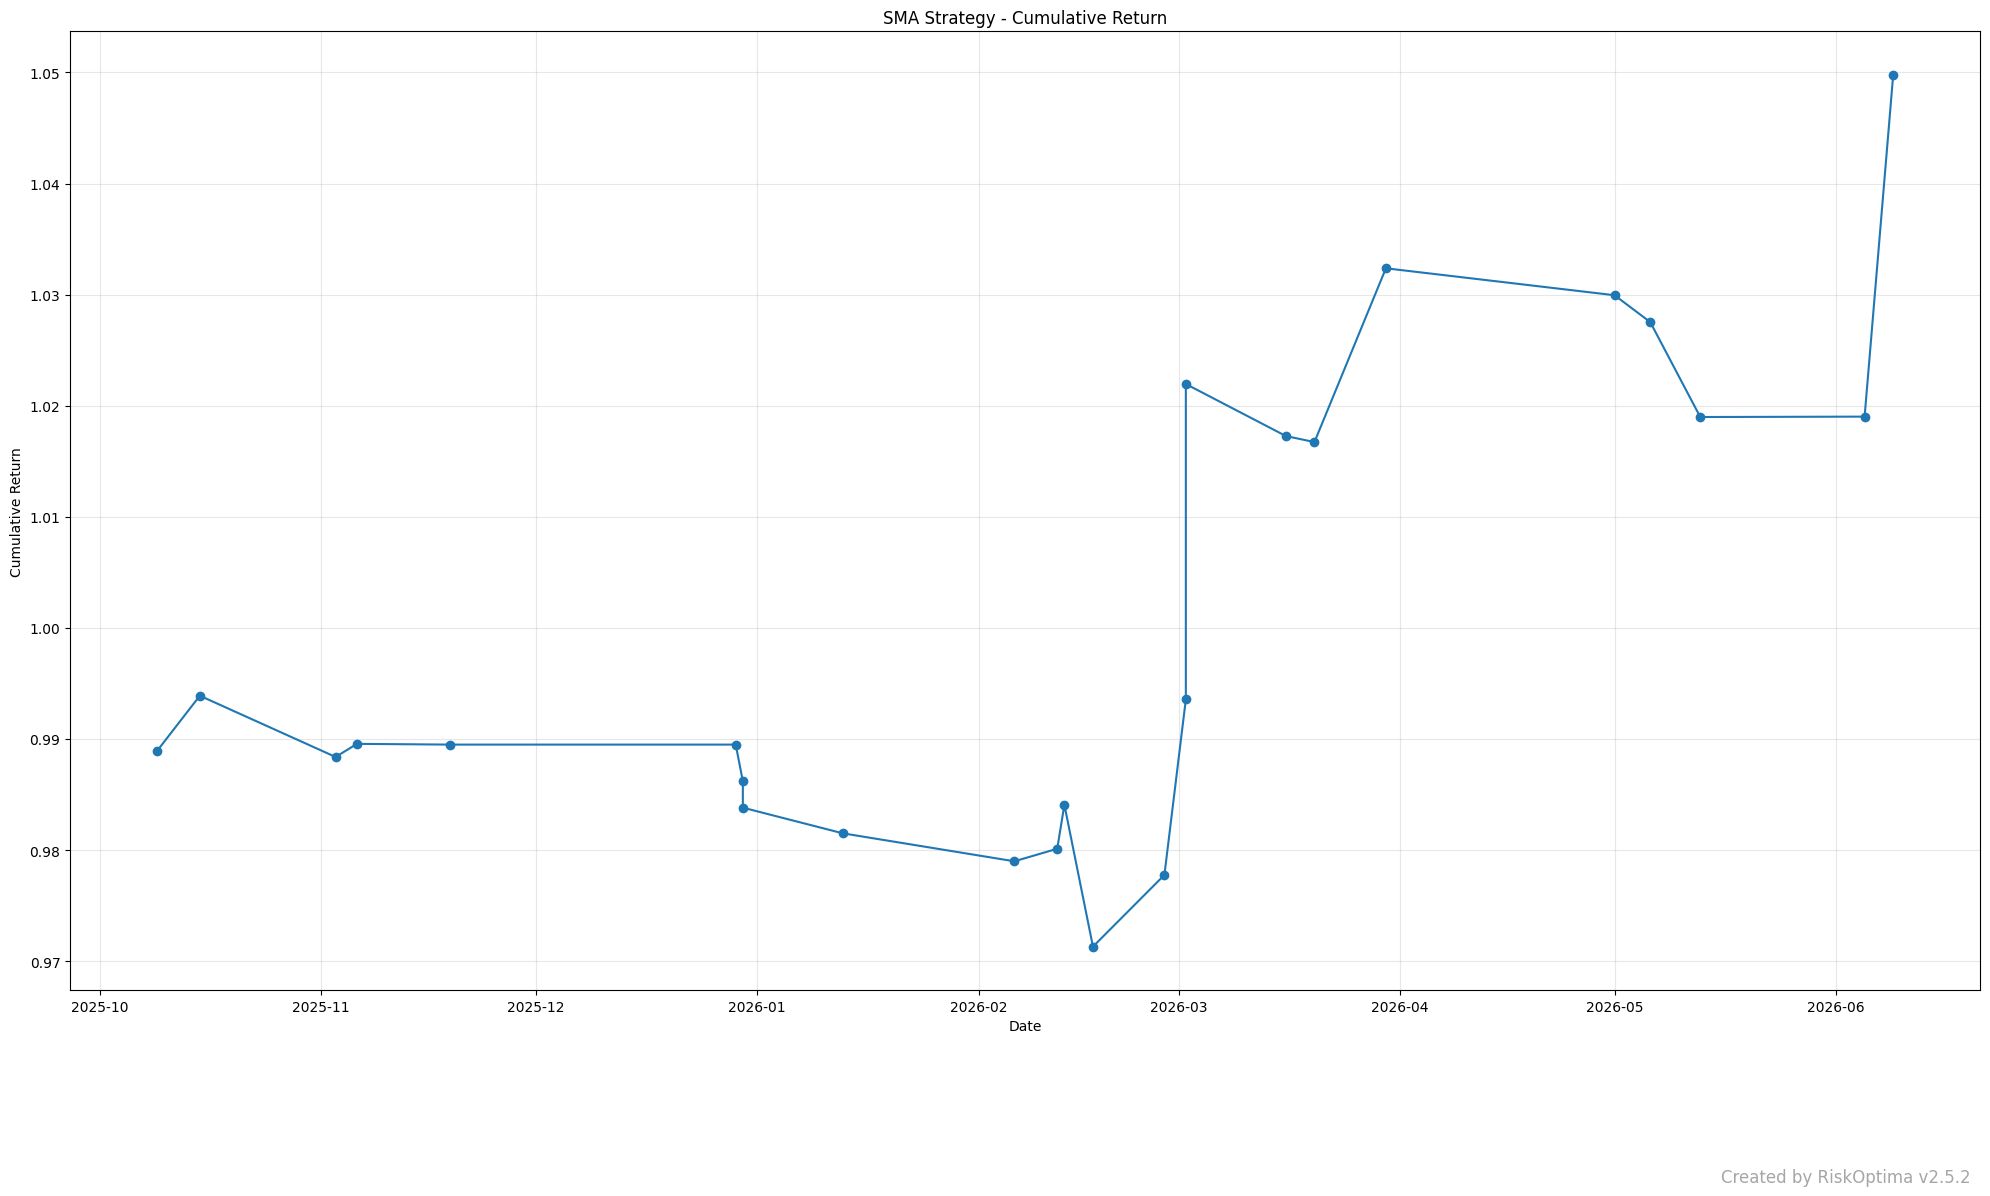

,Ticker,Entry Date,Exit Date,Entry Price,Exit Price,Return,Exit Reason,Weight,Weighted Return
21,MSEX,2025-09-18,2025-10-15,53.099998,58.450001,0.100753,Take Profit,0.05,0.005038
11,NFG,2025-09-24,2025-10-09,92.199997,85.809998,-0.069306,Stop Loss,0.16,-0.011089
3,BKH,2025-10-06,2025-11-06,60.520000,67.750000,0.119465,Take Profit,0.01,0.001195
6,ED,2025-10-16,2025-11-19,101.070000,100.379997,-0.006827,Sell Signal,0.01,-0.000068
8,PEP,2025-10-22,2025-11-03,153.029999,143.600006,-0.061622,Stop Loss,0.09,-0.005546
14,KO,2025-10-28,2025-12-29,70.160004,70.160004,0.000000,Sell Signal,0.06,0.000000
9,PEP,2025-12-10,2025-12-30,149.699997,144.160004,-0.037007,Sell Signal,0.09,-0.003331
16,FRT,2025-12-16,2026-03-02,100.120003,110.339996,0.102077,Take Profit,0.28,0.028582
18,GPC,2025-12-18,2025-12-30,125.930000,124.029999,-0.015088,Sell Signal,0.16,-0.002414
12,NFG,2025-12-19,2026-01-13,81.040001,79.849998,-0.014684,Sell Signal,0.16,-0.002349


In [6]:
# Run for a single ticker
run_and_plot_sma_strategy("SPY", ANALYSIS_START_DATE, ANALYSIS_END_DATE, stop_loss=0.05, take_profit=0.10)

# Run for multiple tickers (equal weights)
run_and_plot_sma_strategy(["SPY", "AAPL", "KO"], ANALYSIS_START_DATE, ANALYSIS_END_DATE, stop_loss=0.05, take_profit=0.10)

# Run using your custom portfolio DataFrame (with weights)
run_and_plot_sma_strategy(asset_table, ANALYSIS_START_DATE, ANALYSIS_END_DATE, stop_loss=0.05, take_profit=0.10)
